<center><span style="font-size:50px;"><b>ANALYSIS OF CUTS ON MC - SINGLE TRACKS</b></span></center>

In this notebook we want to search for the best cuts of the Monte Carlo data, in order to try them later in real data.  
Here we only look for the raw MC data, so the single tracks, NOT the ones obtained after the pairs search (combinatory).

The codes in the pdg for the important particles are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from collections import Counter

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

---

---

---

<center><span style="font-size:35px;"><b>TESTING ACCESS TO DATA</b></span></center>

In [2]:
path = "/home/benedetto/Scrivania/LCP_B/project/MC_raw_data_from_VM/001_010/AO2Dtree.root"

# debug:
file = uproot.open(path)
diction = file.classnames()
for k, v in list(diction.items())[:7]:
    print(k, v)

DF_2303121152302944;1 TDirectory
DF_2303121152302944/O2mccollision;1 TTree
DF_2303121152302944/O2collision_001;1 TTree
DF_2303121152302944/O2filtertrack;1 TTree
DF_2303121152302944/O2filtertrackextr;1 TTree
DF_2303121152302944/O2filtertrackmc;1 TTree
DF_2303121152302944/O2genparticles;1 TTree


In [3]:
# # debug
# file["DF_2303121152302944/O2filtertrackextr"].show()

In [4]:
# # debug
# df_test = file["DF_2303121152302944/O2filtertrackmc"].arrays(library="pd")
# df_test["fMainHfMotherPdgCode"].value_counts()

In [5]:
# debug
df_test = file["DF_2303121152302944/O2filtertrackextr"].arrays(library="pd")
df_test.tail(5)

,fPt,fEta,fCharge,fDcaXY,fDcaZ,fSigmaDcaXY2,fSigmaDcaZ2,fNsigmaTPCpi,fNsigmaTPCka,fNsigmaTPCpr,fNsigmaTOFpi,fNsigmaTOFka,fNsigmaTOFpr
6186,0.520507,-0.750949,1,-0.004341,0.008275,0.000023,0.000035,0.294119,-3.098816,-9.621442,-999.000000,-999.000000,-999.000000
6187,0.657543,0.736443,1,0.002267,-0.003376,0.000025,0.000038,-0.641760,-2.451280,-8.418551,1.816856,-23.598524,-47.244957
6188,1.409657,-0.771347,-1,0.002688,0.002468,0.000007,0.000011,-1.136653,0.636019,-0.777613,0.441942,-7.789932,-19.709839
6189,0.347745,0.792705,-1,0.003879,0.005754,0.000059,0.000097,0.933263,-8.413826,-18.812960,-999.000000,-999.000000,-999.000000
6190,0.459839,0.639778,-1,-0.004815,0.000018,0.000034,0.000049,0.272564,-4.951161,-11.705180,-0.266166,-36.795307,-71.208565


In [6]:
# debug
names_dirs = file.keys(filter_classname="TDirectory")
print(f"We have --{len(names_dirs)}-- directories of data in this chunk.")

We have --314-- directories of data in this chunk.


---

---

---

---

<center><span style="font-size:35px;"><b>UPLOADING DATA</b></span></center>
Here we upload the Trees in the root files.

Choose if you want to upload the already created pickle dataframe (short way) or upload every single tree and merge them (long way).

All the chunks names: 001_010, 011_020, 021_030, 031_040, 041_050, 051_060, 061_070, 071_080, 081_090, 091_100.  

In [7]:
upload_type = "ready_dataframe"

if  upload_type=="ready_dataframe":
    
    df = pd.read_pickle("/home/benedetto/Scrivania/LCP_B/project/MC_raw_data_from_VM/raw_tracks_dataframe.pkl")


elif upload_type=="from_root_files":

    # UPLOAD PATH:
    base_path = "/home/benedetto/Scrivania/LCP_B/project/MC_raw_data_from_VM"
    chunk_list = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
    file_name = "AO2Dtree.root"
    
    # initialization:
    list_for_gloabl_dataframe = []
    
    for i_chunk in chunk_list:
    
        # PATH:
        path = f"{base_path}/{i_chunk}/{file_name}"
        file = uproot.open(path)
        
        # UPLOAD INITIALIZATION
        names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
        names_track      = file.keys(filter_name=r"*O2filtertrack")
        names_coll       = file.keys(filter_name=r"*O2collision_001")
        
        names_mc_gen     = file.keys(filter_name=r"*O2genparticles")
        names_mc_track   = file.keys(filter_name=r"*O2filtertrackmc")
        names_mc_coll    = file.keys(filter_name=r"*O2mccollision")
        
        num = len(names_coll)             # number of directories to unify (like DF_2303121152302944, etc)
        
        list_of_df = []                   # add the dataframes in a list (we will concat them later)
        
        collision_offset =  np.int64(0)   # variable to correct the index of the collision (because it starts from 0 at each new TTree)
        collision_offset_mc = np.int64(0)
        
        for i in range(num):          # cycle over directories (each with 6 TTrees)
        
            # READING DIRECTORIES:
            df_coll = file[ names_coll[i] ].arrays(["fPosZ"], library="pd")
            df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
                 "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTOFpi", "fNsigmaTOFka"], library="pd" )
            df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha", "fX", "fY", "fZ"], library="pd")
            # take the corresponding data of MC and merge it in df_track
            df_track_mc = file[names_mc_track[i]].arrays(["fPdgCode","fMainMotherOrigIndex","fMainHfMotherPdgCode","fMainMotherNfinalStateDaught",
                                                          "fMainBeautyAncestorPdgCode"],library="pd")
            
            df_track = pd.merge(left=df_track, 
                                 right=df_track_mc, 
                                 how='inner', left_index=True, right_index=True)   # I simply create a new dataframe given by those two side by side
            # merge track and trackextr:
            df_trackextr = pd.merge(left=df_trackextr, right=df_track, how='inner', left_index=True, right_index=True)
        
            
            # CUTS_________________________________________________________________________________________________________
            # we cut rows where the fIndexCollision is (for some unknown reason) negative 
            valid = df_trackextr["fIndexCollisions"] >= 0
            df_trackextr = df_trackextr[valid].reset_index(drop=True)  
        
        
            # MERGING COLLISION VARIABLES THROUGH INDEX COLLISION______________________________________________________________
            # Now we add fPosX,Y,Z as new columns (connecting them through fIndexCollisions) and cut over fPosZ
            df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
            df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
        
            # REINDEXING:
            new_indexes_main_mother, _ = pd.factorize(df_trackextr["fMainMotherOrigIndex"], sort=False)
            df_trackextr["fMainMotherOrigIndex"] = new_indexes_main_mother
            new_indexes_collision, _ = pd.factorize(df_trackextr["fIndexCollisions"], sort=False)
            df_trackextr["fIndexCollisions"] = new_indexes_collision
            # UPDATE indexes:
            max_coll_current = df_trackextr["fIndexCollisions"].max()  # raw max
            max_mc_current   = df_trackextr["fMainMotherOrigIndex"].max()  # raw max
            df_trackextr["fIndexCollisions"] += collision_offset
            df_trackextr["fMainMotherOrigIndex"] += collision_offset_mc 
        
            # KEPT VARIABLES ________________________________________________________________________________________________
            # We keep the variables over which we did the cut to see how they behave for the signal
            df_trackextr = df_trackextr[
                            ["fIndexCollisions", "fPdgCode", "fMainHfMotherPdgCode", "fPt", "fCharge", "fDcaXY",
                              "fNsigmaTPCpi", "fNsigmaTPCka","fNsigmaTOFpi", "fNsigmaTOFka",
                              "fMainMotherOrigIndex", "fMainMotherNfinalStateDaught", "fMainBeautyAncestorPdgCode"] ]
        
            list_of_df.append( df_trackextr )              # add the final dataframe in a list (we will concat them later)
            
            # UPDATE OFFSET for next loop:
            collision_offset += max_coll_current + 1
            collision_offset_mc += max_mc_current + 1
        
            # CLEANING SPACE
            del df_track
            del df_trackextr
            del df_coll
            del df_track_mc
        
            # END OF UPLOADING DATA FROM A PART OF A CHUNK_______________________________________________________________________________
    
        # MERGE all the dataframes/directories (of a part of a chunk) in a single dataframe
        df = pd.concat(list_of_df, ignore_index=True)
        N = len(df)
        del list_of_df
        list_for_gloabl_dataframe.append( df )              # add the final dataframe in a list (we will concat them later)
    
    # MERGE all the dataframes/directories (of a part of a chunk) in a single dataframe
    df = pd.concat(list_for_gloabl_dataframe, ignore_index=True)
    N = len(df)
    del list_for_gloabl_dataframe

In [8]:
# Debug
print(f"The uploaded dataframe has {len(df):_} rows and {len(df.columns)} columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"    It occupies {memory:.2f} MB")

display( pd.concat([df.head(5),df.tail(5)]) )

The uploaded dataframe has 23_777_934 rows and 13 columns.
    It occupies 1360.58 MB


,fIndexCollisions,fPdgCode,fMainHfMotherPdgCode,fPt,fCharge,fDcaXY,fNsigmaTPCpi,fNsigmaTPCka,fNsigmaTOFpi,fNsigmaTOFka,fMainMotherOrigIndex,fMainMotherNfinalStateDaught,fMainBeautyAncestorPdgCode
0,0,211,0,1.328234,1,-0.008024,0.745507,1.912507,-1.992263,-11.110423,0,0,0
1,0,-211,0,0.818927,-1,-0.005362,0.089017,-1.574181,-1.437327,-21.357477,0,0,0
2,0,-211,0,1.151065,-1,-0.002529,-1.139159,-0.402068,-4.189509,-15.181988,0,0,0
3,0,211,0,0.596729,1,0.004228,-0.565151,-3.396817,-0.624115,-27.616001,0,0,0
4,0,211,0,0.704289,1,0.008957,0.544025,-2.476945,1918.979858,204.167679,0,0,0
23777929,230193,-211,0,0.612128,-1,0.001860,-0.289177,-2.492355,-999.000000,-999.000000,68092,0,0
23777930,230194,211,0,0.412920,1,0.005722,0.928973,-5.819335,0.594230,-41.551414,68092,0,0
23777931,230195,-211,0,0.698439,-1,-0.003715,0.830908,-0.725767,-999.000000,-999.000000,68092,0,0
23777932,230196,-211,0,0.403408,-1,0.003558,0.971416,-6.285511,-999.000000,-999.000000,68092,0,0
23777933,230196,211,0,0.576050,1,-0.000748,0.080888,-2.989556,-999.000000,-999.000000,68092,0,0


Code to save the uploaded dataframe:

In [9]:
# df.to_pickle("/home/benedetto/Scrivania/LCP_B/project/MC_raw_data_from_VM/raw_tracks_dataframe.pkl")

---

---

## MASK FOR SIGNAL AND BACKGROUND

In [10]:
# DEFINING MASKS (candidate level)
# we use the term 'candidate' cause we also need to check the "fMainMotherOrigIndex" variable (we'll do it later)
candidate_mask_true_k_from_d0 = (
    (df["fPdgCode"] == -321 ) &
    (df["fMainHfMotherPdgCode"] == 421) &
    (df["fMainBeautyAncestorPdgCode"] == 0) &
    (df["fMainMotherNfinalStateDaught"] == 2)
)
candidate_mask_true_k_from_anti_d0 = (
    (df["fPdgCode"] == +321 ) &
    (df["fMainHfMotherPdgCode"] == -421) &
    (df["fMainBeautyAncestorPdgCode"] == 0) &
    (df["fMainMotherNfinalStateDaught"] == 2)
)
candidate_mask_true_pi_from_d0 = (
    (df["fPdgCode"] == +211 ) &
    (df["fMainHfMotherPdgCode"] == 421) &
    (df["fMainBeautyAncestorPdgCode"] == 0) &
    (df["fMainMotherNfinalStateDaught"] == 2)
)
candidate_mask_true_pi_from_anti_d0 = (
    (df["fPdgCode"] == -211 ) &
    (df["fMainHfMotherPdgCode"] == -421) &
    (df["fMainBeautyAncestorPdgCode"] == 0) &
    (df["fMainMotherNfinalStateDaught"] == 2)
)

# ------------------------------------------------------------------
# FIX FOR DUPLICATES: keep ONLY mothers with exactly 1 Kaon and 1 pion
# ------------------------------------------------------------------

# D0
# we obtain the list of all mother indexes and how many particles have a same mother index
kaon_counts_d0 = df[candidate_mask_true_k_from_d0].groupby("fMainMotherOrigIndex").size()
pion_counts_d0 = df[candidate_mask_true_pi_from_d0].groupby("fMainMotherOrigIndex").size()
# we keep only the mother indexes associated to at most 1 particle (we can't have more kaons for the same D0! same thing for pions)
good_d0_indexes = set(kaon_counts_d0[kaon_counts_d0 == 1].index).intersection( set(pion_counts_d0[pion_counts_d0 == 1].index) )

# anti-D0
kaon_counts_ad0 = df[candidate_mask_true_k_from_anti_d0].groupby("fMainMotherOrigIndex").size()
pion_counts_ad0 = df[candidate_mask_true_pi_from_anti_d0].groupby("fMainMotherOrigIndex").size()

good_anti_d0_indexes = set(kaon_counts_ad0[kaon_counts_ad0 == 1].index).intersection( set(pion_counts_ad0[pion_counts_ad0 == 1].index) )

# ------------------------------------------------------------------
# FINAL MASKS (using only the "good" mothers)
# ------------------------------------------------------------------

mask_true_k_from_d0 = (       candidate_mask_true_k_from_d0 & df["fMainMotherOrigIndex"].isin(good_d0_indexes) )
mask_true_pi_from_d0 = (      candidate_mask_true_pi_from_d0 & df["fMainMotherOrigIndex"].isin(good_d0_indexes) )
mask_true_k_from_anti_d0 = (  candidate_mask_true_k_from_anti_d0 &  df["fMainMotherOrigIndex"].isin(good_anti_d0_indexes) )
mask_true_pi_from_anti_d0 = ( candidate_mask_true_pi_from_anti_d0 & df["fMainMotherOrigIndex"].isin(good_anti_d0_indexes) )

mask_signal = ( mask_true_k_from_d0 | mask_true_pi_from_d0 | mask_true_k_from_anti_d0 | mask_true_pi_from_anti_d0 )
mask_background = ~mask_signal
mask_true_k = ( mask_true_k_from_d0 | mask_true_k_from_anti_d0 )
mask_true_pi = ( mask_true_pi_from_d0 | mask_true_pi_from_anti_d0 )
mask_true_d0 = ( mask_true_k_from_d0 | mask_true_pi_from_d0 )
mask_true_anti_d0 = ( mask_true_k_from_anti_d0 | mask_true_pi_from_anti_d0 )

WATCH OUT: There are D0s with more than two daughters particles (so like more pions and/or more kaons with the same fMainMotherOrigIndex), even when they all have fMainMotherNfinalStateDaught==2!!

To check it, run this modified lines:
```python
# here we do not impose to have a single particle per index (for both pions and kaons)
good_d0_indexes = set(kaon_counts_d0.index).intersection( set(pion_counts_d0.index) ) 
good_anti_d0_indexes = set(kaon_counts_ad0.index).intersection( set(pion_counts_ad0.index) )

# test lines:
tmp = df[mask_true_k_from_d0 | mask_true_pi_from_d0]    # this includes all kaon and pion tracks from D0 decays
counts = tmp.groupby("fMainMotherOrigIndex")["fPdgCode"].count()
print(counts.value_counts())
```
The output will be something like:
```
fPdgCode
2    6522
3    1277
4     226
5      27
6       5
Name: count, dtype: int64
```
We solved the problem by choosing as 'true' D0 only the ones with a single couple of particles: a $\pi$ and a $K$.  
But another choice could be keeping them all and modify the way to count them.

In [11]:
# test lines:
tmp = df[mask_true_k_from_d0 | mask_true_pi_from_d0]
counts = tmp.groupby("fMainMotherOrigIndex")["fPdgCode"].count()
print(counts.value_counts())

fPdgCode
2    13320
Name: count, dtype: int64


In [12]:
# ------------------------------------------------------------------
# ADD TRUTH LABEL AND DROP EXTRA COLUMNS
# ------------------------------------------------------------------
df["truth"] = np.select( [mask_true_d0, mask_true_anti_d0], [1, -1], default=0 )

summarized_cols = [
    "fPdgCode",
    "fMainHfMotherPdgCode",
    "fMainBeautyAncestorPdgCode",
    "fMainMotherNfinalStateDaught",
    "fMainMotherOrigIndex"
]
df = df.drop(columns=summarized_cols)

In [13]:
# Debug
print(f"The uploaded dataframe has {len(df):_} rows and {len(df.columns)} columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"    It occupies {memory:.2f} MB")

display( pd.concat([df.head(5),df.tail(5)]) )

The uploaded dataframe has 23_777_934 rows and 9 columns.
    It occupies 997.76 MB


,fIndexCollisions,fPt,fCharge,fDcaXY,fNsigmaTPCpi,fNsigmaTPCka,fNsigmaTOFpi,fNsigmaTOFka,truth
0,0,1.328234,1,-0.008024,0.745507,1.912507,-1.992263,-11.110423,0
1,0,0.818927,-1,-0.005362,0.089017,-1.574181,-1.437327,-21.357477,0
2,0,1.151065,-1,-0.002529,-1.139159,-0.402068,-4.189509,-15.181988,0
3,0,0.596729,1,0.004228,-0.565151,-3.396817,-0.624115,-27.616001,0
4,0,0.704289,1,0.008957,0.544025,-2.476945,1918.979858,204.167679,0
23777929,230193,0.612128,-1,0.001860,-0.289177,-2.492355,-999.000000,-999.000000,0
23777930,230194,0.412920,1,0.005722,0.928973,-5.819335,0.594230,-41.551414,0
23777931,230195,0.698439,-1,-0.003715,0.830908,-0.725767,-999.000000,-999.000000,0
23777932,230196,0.403408,-1,0.003558,0.971416,-6.285511,-999.000000,-999.000000,0
23777933,230196,0.576050,1,-0.000748,0.080888,-2.989556,-999.000000,-999.000000,0


In [14]:
# simple renaiming
final_results = df

In [15]:
d0_tot = mask_true_d0.sum()/2
anti_d0_tot = mask_true_anti_d0.sum()/2
signal_total = d0_tot + anti_d0_tot
print(f"We have {mask_true_d0.sum()} tracks coming from D0 decays, i.e. {d0_tot:.0f} D0 mesons.")
print(f"We have {mask_true_anti_d0.sum()} tracks coming from anti-D0 decays, i.e. {anti_d0_tot:.0f} anti-D0 mesons.")
print(f"SO we have a total of {signal_total:.0f} of signal mother particles (D0 and anti-D0).\n")

print(f"We have {mask_true_k.sum()} true kaon (K±) tracks from D0 or anti-D0 decays.")
print(f"We have {mask_true_pi.sum()} true pion (pi±) tracks from D0 or anti-D0 decays.\n")

print(f"We have {mask_signal.sum()} total signal tracks.")
print(f"We have {mask_background.sum():_} total background tracks.")

We have 26640 tracks coming from D0 decays, i.e. 13320 D0 mesons.
We have 27804 tracks coming from anti-D0 decays, i.e. 13902 anti-D0 mesons.
SO we have a total of 27222 of signal mother particles (D0 and anti-D0).

We have 27222 true kaon (K±) tracks from D0 or anti-D0 decays.
We have 27222 true pion (pi±) tracks from D0 or anti-D0 decays.

We have 54444 total signal tracks.
We have 23_723_490 total background tracks.


The variables we have to work with are:

In [16]:
print(final_results.columns)

Index(['fIndexCollisions', 'fPt', 'fCharge', 'fDcaXY', 'fNsigmaTPCpi',
       'fNsigmaTPCka', 'fNsigmaTOFpi', 'fNsigmaTOFka', 'truth'],
      dtype='object')


---

---

---

<center><span style="font-size:35px;"><b>TRACK VARIABLES DISTRIBUTION</b></span></center>

Let's study the distribution of the variables for the known correct tracks. In this way we can do better cuts.

### $p_T$ OF SINGLE TRACKS

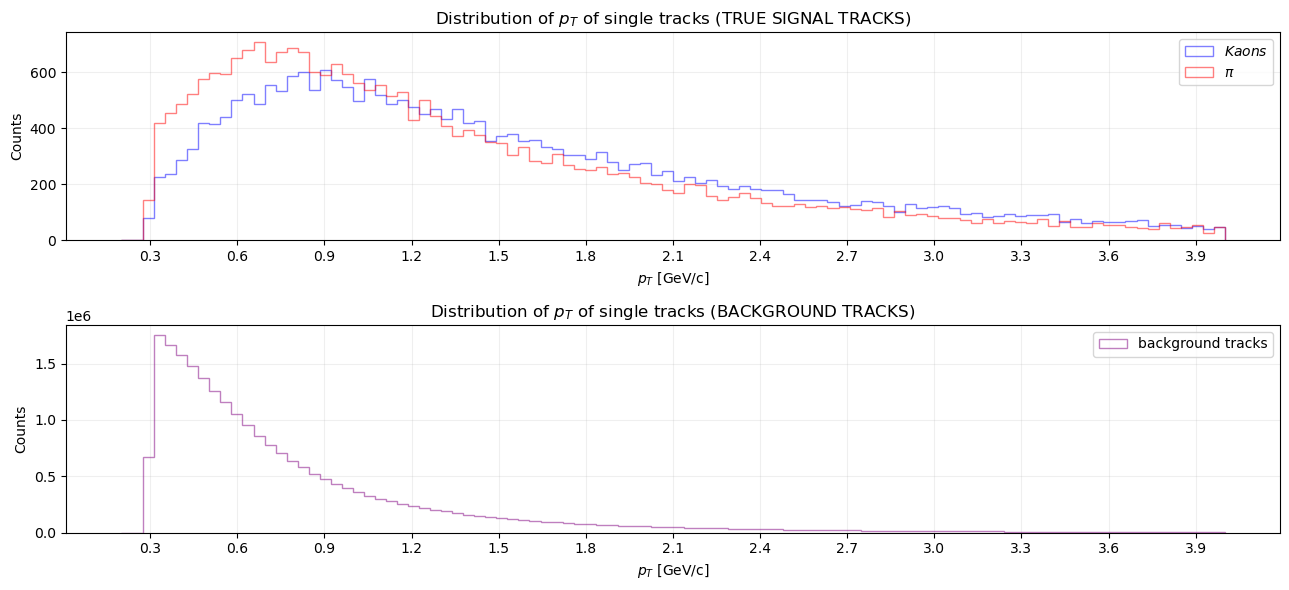

In [17]:
N_BINS = 100
range_min = 0.2
range_max = 4

num_of_plots = 2
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,3*num_of_plots)  )

# TRUE SIGNAL ---------------------------------------- 
data = final_results.loc[ mask_true_k, "fPt" ]
axs[0].hist( data , bins=N_BINS, range=(range_min, range_max), color="blue", alpha=0.5, label=r"$Kaons$", histtype='step')
data = final_results.loc[ mask_true_pi, "fPt" ]
axs[0].hist( data , bins=N_BINS, range=(range_min, range_max), color="red",  alpha=0.5, label=r"$\pi$", histtype='step')
axs[0].set_xlabel(r"$p_T$ [GeV/c]")
axs[0].set_ylabel("Counts")
axs[0].set_title(r"Distribution of $p_T$ of single tracks (TRUE SIGNAL TRACKS)")
axs[0].set_xticks(np.arange(0.3, range_max, 0.3))
axs[0].grid(alpha=0.2)
axs[0].legend()

# BACKGROUND ---------------------------------------- 
data = final_results.loc[ mask_background, "fPt" ]
axs[1].hist( data , bins=N_BINS, range=(range_min, range_max), color="purple", alpha=0.5, label="background tracks", histtype='step')
axs[1].set_xlabel(r"$p_T$ [GeV/c]")
axs[1].set_ylabel("Counts")
axs[1].set_title(r"Distribution of $p_T$ of single tracks (BACKGROUND TRACKS)")
axs[1].set_xticks(np.arange(0.3, range_max, 0.3))
axs[1].grid(alpha=0.2)
axs[1].legend()

plt.tight_layout()
plt.show()

del data

The signal si present at higher ratio for high $p_T$ values.

### $\pi^+$ TRACKS
Let's observe the distribution of the variables for the $\pi^+$ tracks, for both the known $D_0$ and also for all the combinatory background.

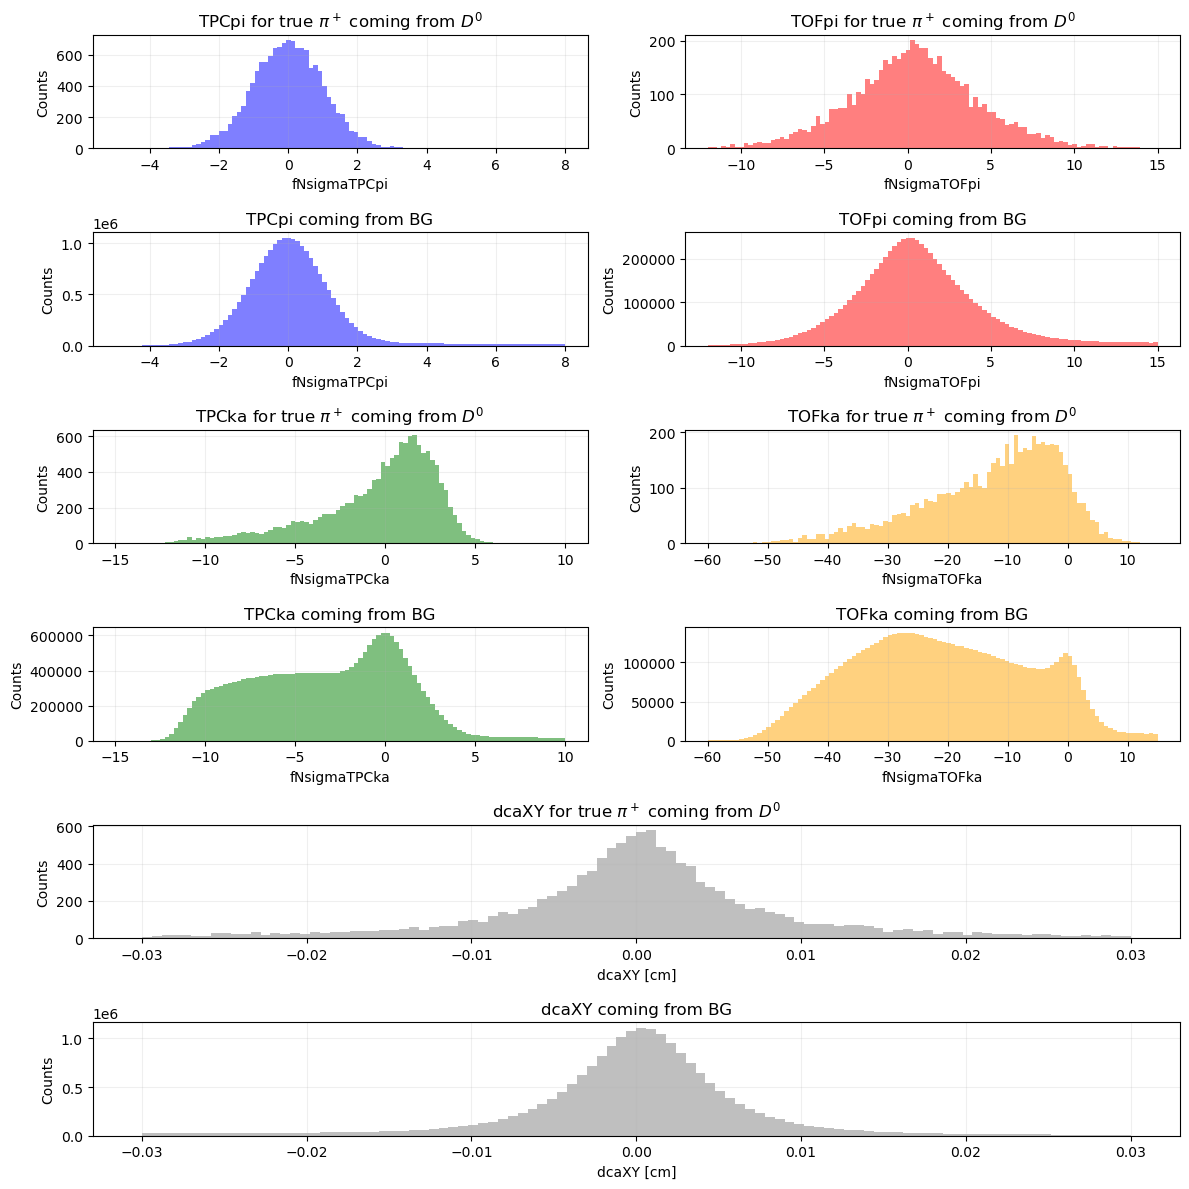

In [18]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_D0", "tofpi_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["tpcka_D0", "tofka_D0"],
    ["tpcka_all", "tofka_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 12)
)

# ============================================================
# --------------- pi variabs ------------------------------
# --- Plot TPCpi for TRUE D0 ---
data = final_results.loc[ mask_true_pi_from_d0, 'fNsigmaTPCpi'].values
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5, range=(-5, 8))
axes["tpcpi_D0"].set_title(r"TPCpi for true $\pi^+$ coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")
axes["tpcpi_D0"].grid(alpha=0.2)

# --- Plot TOFpi con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[ mask_true_pi_from_d0, 'fNsigmaTOFpi'].values
axes["tofpi_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5, range=(-12, 15))
axes["tofpi_D0"].set_title(r"TOFpi for true $\pi^+$ coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")
axes["tofpi_D0"].grid(alpha=0.2)

# --- Plot TPCpi FOR BG---
data = final_results.loc[ mask_background , 'fNsigmaTPCpi'].values
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5, range=(-5, 8))
axes["tpcpi_all"].set_title(r"TPCpi coming from BG")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")
axes["tpcpi_all"].grid(alpha=0.2)

# --- Plot TOFpi con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results.loc[  mask_background, 'fNsigmaTOFpi'].values
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5, range=(-12, 15))
axes["tofpi_all"].set_title(r"TOFpi coming from BG")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")
axes["tofpi_all"].grid(alpha=0.2)

# ============================================================
# --------------- ka variabs ------------------------------
# --- Plot TPCka for TRUE D0 ---
data = final_results.loc[mask_true_pi_from_d0, 'fNsigmaTPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5, range=(-15, 10))
axes["tpcka_D0"].set_title(r"TPCka for true $\pi^+$ coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")
axes["tpcka_D0"].grid(alpha=0.2)

# --- Plot TOFka con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[mask_true_pi_from_d0, 'fNsigmaTOFka'].values
axes["tofka_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5, range=(-60, 15))
axes["tofka_D0"].set_title(r"TOFka for true $\pi^+$ coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")
axes["tofka_D0"].grid(alpha=0.2)

# --- Plot TPCka FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCka'].values
axes["tpcka_all"].hist(data, bins=N_BINS, color="green", alpha=0.5, range=(-15, 10))
axes["tpcka_all"].set_title(r"TPCka coming from BG")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")
axes["tpcka_all"].grid(alpha=0.2)

# --- Plot TOFka con filtro (-12, 12) FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFka'].values
axes["tofka_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5, range=(-60, 15))
axes["tofka_all"].set_title(r"TOFka coming from BG")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")
axes["tofka_all"].grid(alpha=0.2)

# ============================================================
#---------------------  dcaXY ---------------------------------------------
# --- Plot dcaXY for TRUE D0 ---
data = final_results.loc[mask_true_pi_from_d0, 'fDcaXY'].values
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="grey", alpha=0.5, range=(-0.03, 0.03))
axes["dcaxy_D0"].set_title(r"dcaXY for true $\pi^+$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY [cm]")
axes["dcaxy_D0"].set_ylabel("Counts")
axes["dcaxy_D0"].grid(alpha=0.2)

# --- Plot dcaXY FOR BG ---
data = final_results.loc[mask_background, 'fDcaXY'].values
axes["dcaxy_all"].hist(data, bins=N_BINS, color="grey", alpha=0.5, range=(-0.03, 0.03))
axes["dcaxy_all"].set_title(r"dcaXY coming from BG")
axes["dcaxy_all"].set_xlabel("dcaXY [cm]")
axes["dcaxy_all"].set_ylabel("Counts")
axes["dcaxy_all"].grid(alpha=0.2)

plt.tight_layout()
plt.show()

del data


As we can see, while TPCpi and TOFpi have the same distribution for TRUE signal and BG, TPCka and TOFka are different. We will discuss this later.

### $\pi^-$ TRACKS
Let's observe the distribution of the variables for the $\pi^-$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

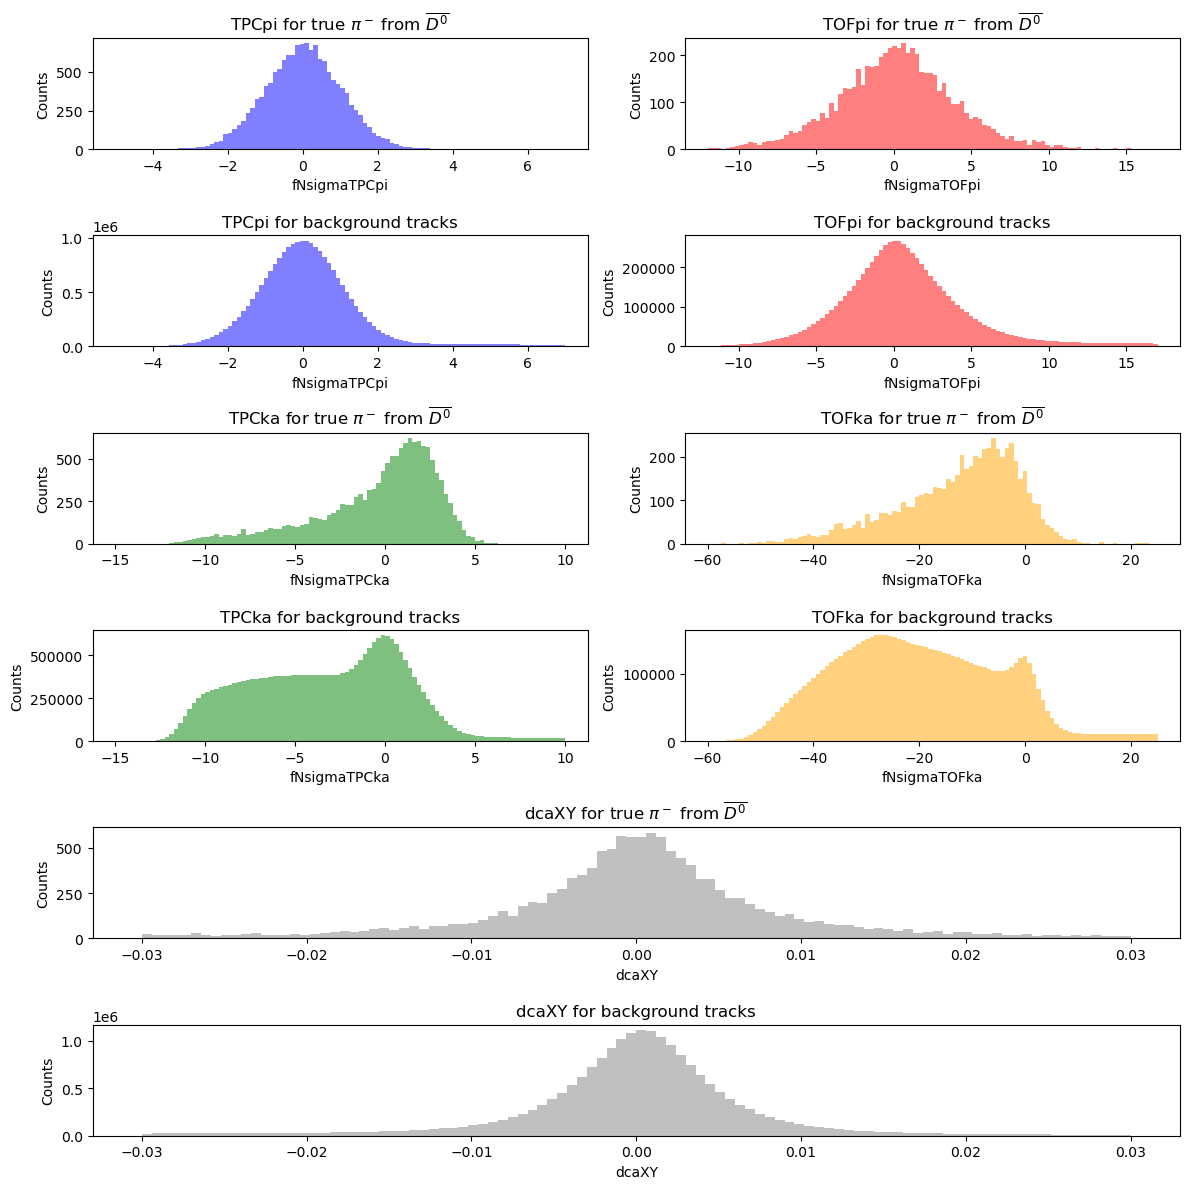

In [19]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_anti_D0", "tofpi_anti_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["tpcka_anti_D0", "tofka_anti_D0"],
    ["tpcka_all", "tofka_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"],
]

fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 12)
)

# ============================================================
# --------------- pi variabs ------------------------------
# TPCpi for TRUE anti-D0
data = final_results.loc[mask_true_pi_from_anti_d0, 'fNsigmaTPCpi'].values
axes["tpcpi_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5, range=(-5, 7))
axes["tpcpi_anti_D0"].set_title(r"TPCpi for true $\pi^-$ from $\overline{D^0}$")
axes["tpcpi_anti_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_anti_D0"].set_ylabel("Counts")

# TOFpi for TRUE anti-D0
data = final_results.loc[mask_true_pi_from_anti_d0, 'fNsigmaTOFpi'].values
axes["tofpi_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5, range=(-12, 17))
axes["tofpi_anti_D0"].set_title(r"TOFpi for true $\pi^-$ from $\overline{D^0}$")
axes["tofpi_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_anti_D0"].set_ylabel("Counts")

# TPCpi for BACKGROUND
data = final_results.loc[mask_background, 'fNsigmaTPCpi'].values
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5, range=(-5, 7))
axes["tpcpi_all"].set_title(r"TPCpi for background tracks")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# TOFpi for BACKGROUND
data = final_results.loc[mask_background, 'fNsigmaTOFpi'].values
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5, range=(-12, 17))
axes["tofpi_all"].set_title(r"TOFpi for background tracks")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# ============================================================
# --------------- ka variabs ------------------------------
# TPCka for TRUE anti-D0
data = final_results.loc[mask_true_pi_from_anti_d0, 'fNsigmaTPCka'].values
axes["tpcka_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5, range=(-15, 10))
axes["tpcka_anti_D0"].set_title(r"TPCka for true $\pi^-$ from $\overline{D^0}$")
axes["tpcka_anti_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_anti_D0"].set_ylabel("Counts")

# TOFka for TRUE anti-D0
data = final_results.loc[mask_true_pi_from_anti_d0, 'fNsigmaTOFka'].values
axes["tofka_anti_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5, range=(-60, 25))
axes["tofka_anti_D0"].set_title(r"TOFka for true $\pi^-$ from $\overline{D^0}$")
axes["tofka_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_anti_D0"].set_ylabel("Counts")

# TPCka for BACKGROUND
data = final_results.loc[mask_background, 'fNsigmaTPCka'].values
axes["tpcka_all"].hist(data, bins=N_BINS, color="green", alpha=0.5, range=(-15, 10))
axes["tpcka_all"].set_title(r"TPCka for background tracks")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# TOFka for BACKGROUND
data = final_results.loc[mask_background, 'fNsigmaTOFka'].values
axes["tofka_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5, range=(-60, 25))
axes["tofka_all"].set_title(r"TOFka for background tracks")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# ============================================================
# --------------- dcaXY ------------------------------
# DCAxy for TRUE anti-D0
data = final_results.loc[mask_true_pi_from_anti_d0, 'fDcaXY'].values
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5, range=(-0.03, 0.03))
axes["dcaxy_anti_D0"].set_title(r"dcaXY for true $\pi^-$ from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# DCAxy for BACKGROUND
data = final_results.loc[mask_background, 'fDcaXY'].values
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5, range=(-0.03, 0.03))
axes["dcaxy_all"].set_title(r"dcaXY for background tracks")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


Same results as before.

### $K^-$ TRACKS
Let's observe the distribution of the variables for the $Kaons^-$ tracks, for both the known $D_0$ and also for all the combinatory background.

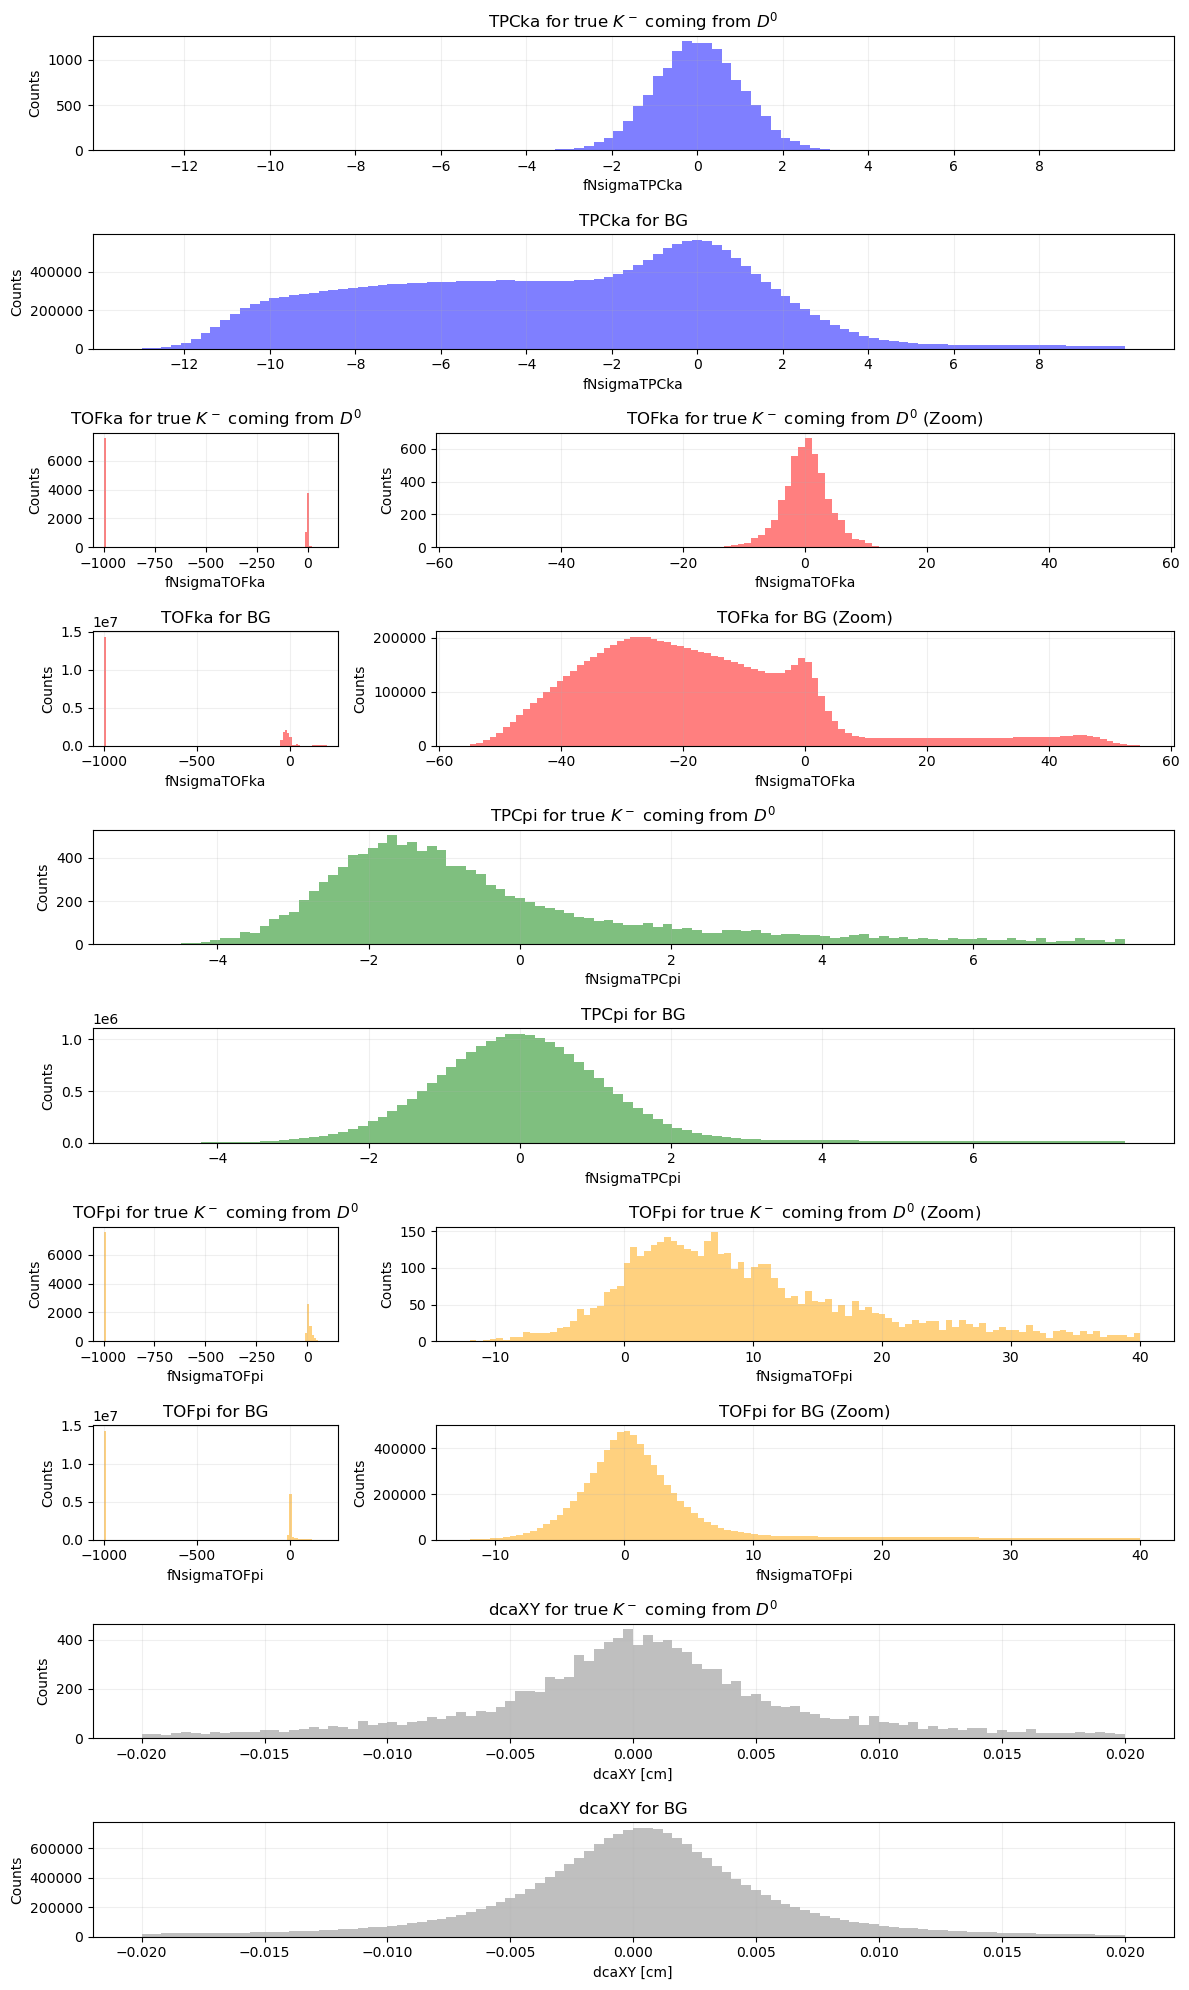

In [20]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_D0", "tpcka_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_D0", "tofka_zoom_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["tpcpi_D0", "tpcpi_D0"],
    ["tpcpi_all", "tpcpi_all"],
    ["tofpi_D0", "tofpi_zoom_D0"],
    ["tofpi_all", "tofpi_zoom_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# ============================================================
# --------------- ka variabs ------------------------------
# --- Plot TPCka FOR TRUE D0---
data = final_results.loc[mask_true_k_from_d0, 'fNsigmaTPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5, range=(-13, 10))
axes["tpcka_D0"].set_title(r"TPCka for true $K^-$ coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")
axes["tpcka_D0"].set_xticks(np.arange(-12, 10, 2))
axes["tpcka_D0"].grid(alpha=0.2)

# --- Plot TPCka FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCka'].values
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5, range=(-13, 10))
axes["tpcka_all"].set_title(r"TPCka for BG")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")
axes["tpcka_all"].set_xticks(np.arange(-12, 10, 2))
axes["tpcka_all"].grid(alpha=0.2)

# --- Plot TOFka FOR TRUE D0 ---
data = final_results.loc[mask_true_k_from_d0, 'fNsigmaTOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_D0"].set_title(r"TOFka for true $K^-$ coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")
axes["tofka_D0"].grid(alpha=0.2)

# --- Plot TOFka zoom (-12,12) FOR TRUE D0 ---
axes["tofka_zoom_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5, range=(-55, 55))
axes["tofka_zoom_D0"].set_title(r"TOFka for true $K^-$ coming from $D^0$ (Zoom)")
axes["tofka_zoom_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_D0"].set_ylabel("Counts")
axes["tofka_zoom_D0"].grid(alpha=0.2)

# --- Plot TOFka completo FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for BG")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")
axes["tofka_all"].grid(alpha=0.2)

# --- Plot TOFka zoom FOR ALL PAIRS ---
axes["tofka_zoom_all"].hist(data, bins=N_BINS, color="red", alpha=0.5, range=(-55, 55))
axes["tofka_zoom_all"].set_title(r"TOFka for BG (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")
axes["tofka_zoom_all"].grid(alpha=0.2)

# ============================================================
# --------------- pi variabs ------------------------------
# --- Plot TPCpi FOR TRUE D0 ---
data = final_results.loc[mask_true_k_from_d0, 'fNsigmaTPCpi'].values
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5, range=(-5, 8))
axes["tpcpi_D0"].set_title(r"TPCpi for true $K^-$ coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")
axes["tpcpi_D0"].set_xticks(np.arange(-4, 8, 2))
axes["tpcpi_D0"].grid(alpha=0.2)

# --- Plot TPCpi FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCpi'].values
axes["tpcpi_all"].hist(data, bins=N_BINS, color="green", alpha=0.5, range=(-5, 8))
axes["tpcpi_all"].set_title(r"TPCpi for BG")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")
axes["tpcpi_all"].set_xticks(np.arange(-4, 8, 2))
axes["tpcpi_all"].grid(alpha=0.2)

# --- Plot TOFpi completo FOR TRUE D0 ---
data = final_results.loc[mask_true_k_from_d0, 'fNsigmaTOFpi'].values
data = data[(data > -1000) & (data < 100)]
axes["tofpi_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_D0"].set_title(r"TOFpi for true $K^-$ coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")
axes["tofpi_D0"].grid(alpha=0.2)

# --- Plot TOFpi zoom (-12,12) FOR TRUE D0 ---
axes["tofpi_zoom_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5, range=(-12, 40))
axes["tofpi_zoom_D0"].set_title(r"TOFpi for true $K^-$ coming from $D^0$ (Zoom)")
axes["tofpi_zoom_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_D0"].set_ylabel("Counts")
axes["tofpi_zoom_D0"].grid(alpha=0.2)

# --- Plot TOFpi completo FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFpi'].values
data = data[(data > -1000) & (data < 200)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for BG")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")
axes["tofpi_all"].grid(alpha=0.2)

# --- Plot TOFpi zoom FOR BG ---
axes["tofpi_zoom_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5, range=(-12, 40))
axes["tofpi_zoom_all"].set_title(r"TOFpi for BG (Zoom)")
axes["tofpi_zoom_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_all"].set_ylabel("Counts")
axes["tofpi_zoom_all"].grid(alpha=0.2)

# ============================================================
# --------------- dcaXY ------------------------------
# --- Plot dcaXY FOR TRUE D0 ---
data = final_results.loc[mask_true_k_from_d0, 'fDcaXY'].values
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5, range=(-0.02, 0.02))
axes["dcaxy_D0"].set_title(r"dcaXY for true $K^-$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY [cm]")
axes["dcaxy_D0"].set_ylabel("Counts")
axes["dcaxy_D0"].grid(alpha=0.2)

# --- Plot dcaXY FOR BG ---
data = final_results.loc[mask_background, 'fDcaXY'].values
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5, range=(-0.02, 0.02))
axes["dcaxy_all"].set_title(r"dcaXY for BG")
axes["dcaxy_all"].set_xlabel("dcaXY [cm]")
axes["dcaxy_all"].set_ylabel("Counts")
axes["dcaxy_all"].grid(alpha=0.2)

plt.tight_layout()
plt.show()
del data

This time, TPCka and TOFka are very informative! This is probably because the majority of the background is formed of pions, so it's much more difficult to distinguish 'our' pions from the others.

### $K^+$ TRACKS
Let's observe the distribution of the variables for the $Kaons^+$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

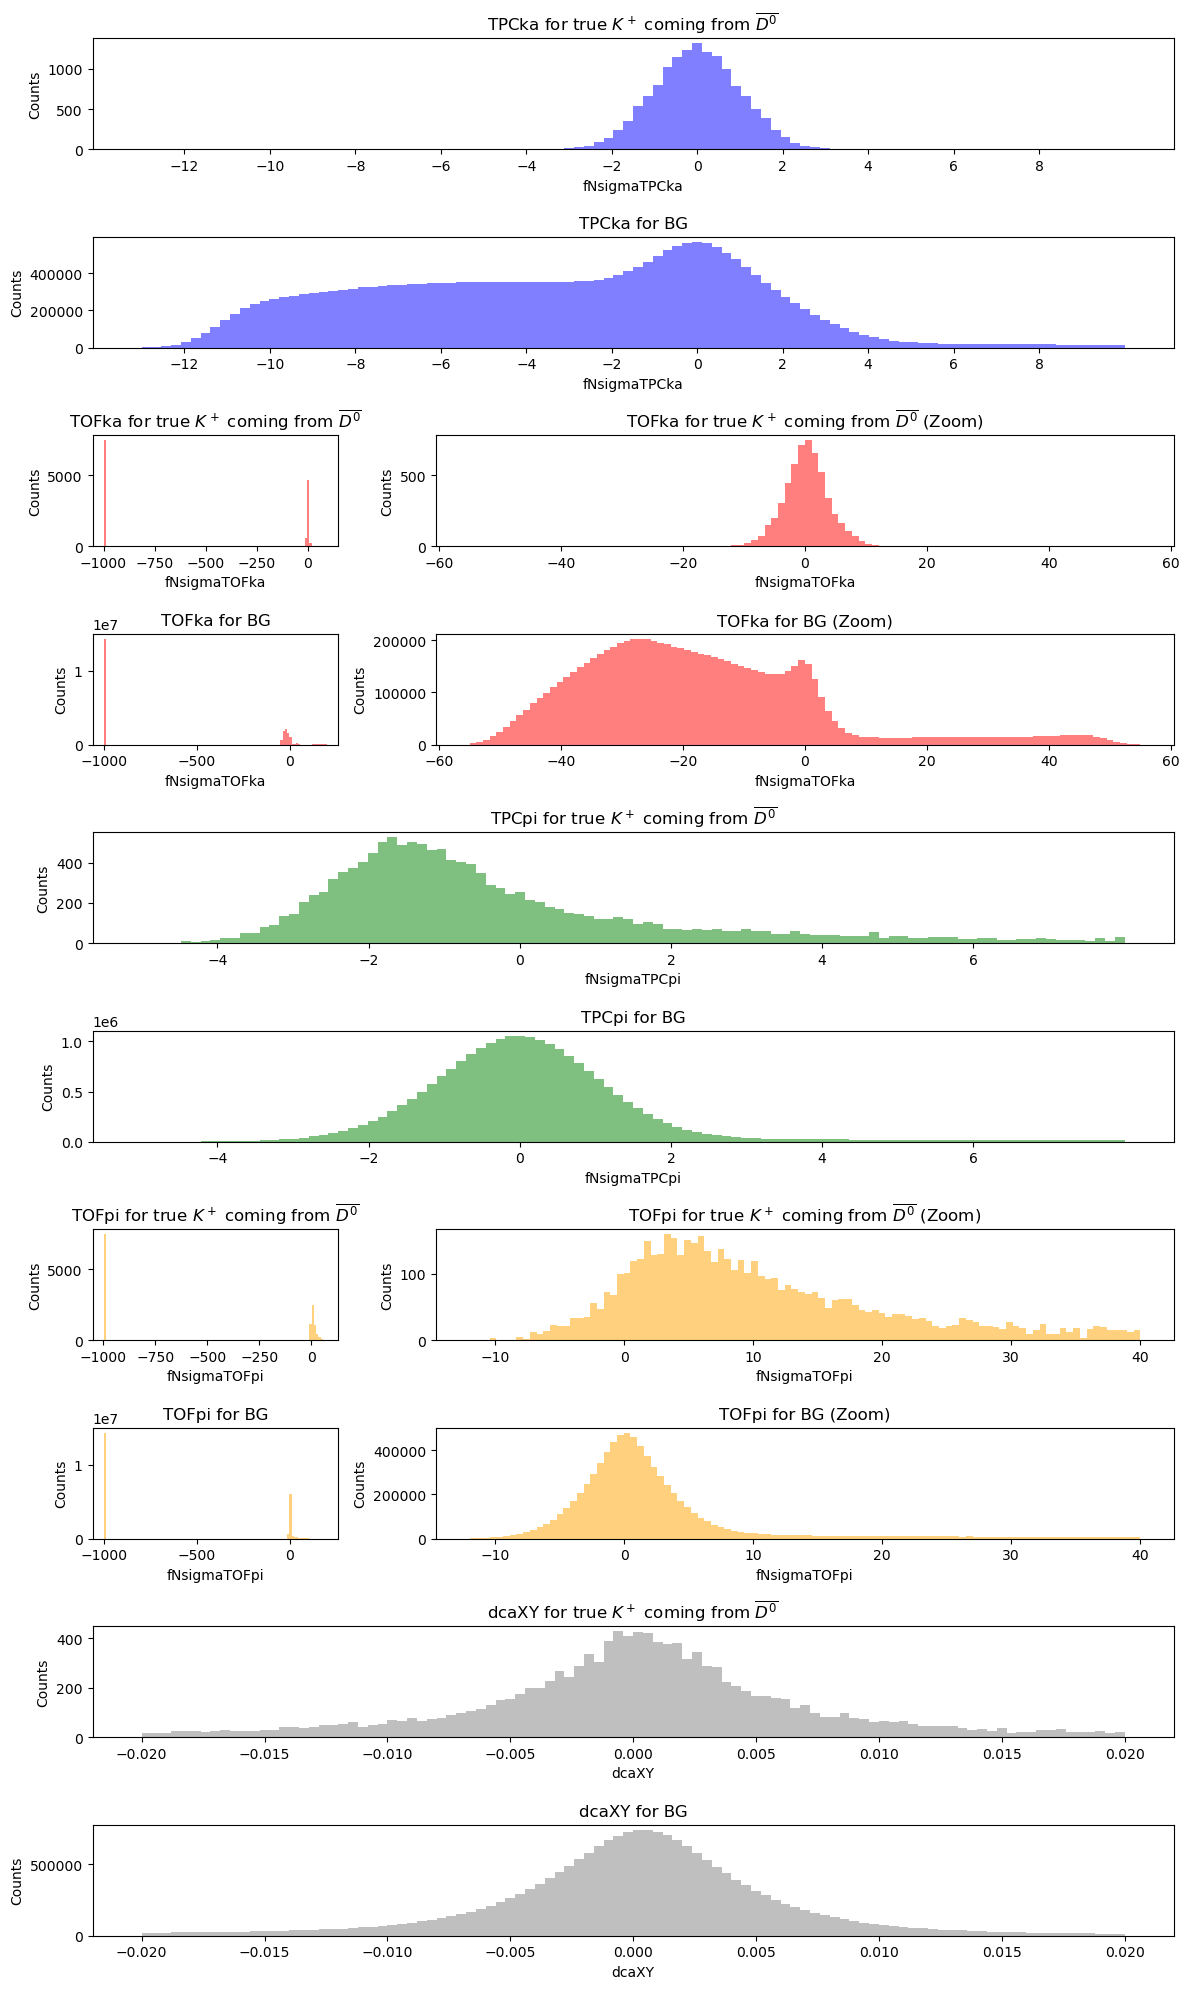

In [21]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_anti_D0", "tpcka_anti_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_anti_D0", "tofka_zoom_anti_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["tpcpi_anti_D0", "tpcpi_anti_D0"],
    ["tpcpi_all", "tpcpi_all"],
    ["tofpi_anti_D0", "tofpi_zoom_anti_D0"],
    ["tofpi_all", "tofpi_zoom_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# ============================================================
# --------------- ka variabs ------------------------------
# --- Plot TPCka FOR TRUE anti_D0---
data = final_results.loc[mask_true_k_from_anti_d0, 'fNsigmaTPCka'].values
axes["tpcka_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5, range=(-13, 10))
axes["tpcka_anti_D0"].set_title(r"TPCka for true $K^+$ coming from $\overline{D^0}$")
axes["tpcka_anti_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_anti_D0"].set_ylabel("Counts")
axes["tpcka_anti_D0"].set_xticks(np.arange(-12, 10, 2))

# --- Plot TPCka FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCka'].values
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5, range=(-13, 10))
axes["tpcka_all"].set_title(r"TPCka for BG")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")
axes["tpcka_all"].set_xticks(np.arange(-12, 10, 2))

# --- Plot TOFka completo FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_k_from_anti_d0, 'fNsigmaTOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_anti_D0"].set_title(r"TOFka for true $K^+$ coming from $\overline{D^0}$")
axes["tofka_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR TRUE anti_D0 ---
axes["tofka_zoom_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5, range=(-55, 55))
axes["tofka_zoom_anti_D0"].set_title(r"TOFka for true $K^+$ coming from $\overline{D^0}$ (Zoom)")
axes["tofka_zoom_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for BG")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR BG ---
axes["tofka_zoom_all"].hist(data, bins=N_BINS, color="red", alpha=0.5, range=(-55, 55))
axes["tofka_zoom_all"].set_title(r"TOFka for BG (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")

# ============================================================
# --------------- pi variabs ------------------------------
# --- Plot TPCpi FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_k_from_anti_d0, 'fNsigmaTPCpi'].values
axes["tpcpi_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5, range=(-5, 8))
axes["tpcpi_anti_D0"].set_title(r"TPCpi for true $K^+$ coming from $\overline{D^0}$")
axes["tpcpi_anti_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_anti_D0"].set_ylabel("Counts")
axes["tpcpi_anti_D0"].set_xticks(np.arange(-4, 8, 2))

# --- Plot TPCpi FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTPCpi'].values
axes["tpcpi_all"].hist(data, bins=N_BINS, color="green", alpha=0.5, range=(-5, 8))
axes["tpcpi_all"].set_title(r"TPCpi for BG")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")
axes["tpcpi_all"].set_xticks(np.arange(-4, 8, 2))

# --- Plot TOFpi completo FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_k_from_anti_d0, 'fNsigmaTOFpi'].values
data = data[(data > -1000) & (data < 100)]
axes["tofpi_anti_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_anti_D0"].set_title(r"TOFpi for true $K^+$ coming from $\overline{D^0}$")
axes["tofpi_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi zoom (-12,12) FOR TRUE anti_D0 ---
axes["tofpi_zoom_anti_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5, range=(-12, 40))
axes["tofpi_zoom_anti_D0"].set_title(r"TOFpi for true $K^+$ coming from $\overline{D^0}$ (Zoom)")
axes["tofpi_zoom_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR BG ---
data = final_results.loc[mask_background, 'fNsigmaTOFpi'].values
data = data[(data > -1000) & (data < 200)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for BG")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot TOFpi zoom FOR BG ---
axes["tofpi_zoom_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5, range=(-12, 40))
axes["tofpi_zoom_all"].set_title(r"TOFpi for BG (Zoom)")
axes["tofpi_zoom_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_all"].set_ylabel("Counts")

# ============================================================
# --------------- dcaXY ------------------------------
# --- Plot dcaXY FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_k_from_anti_d0, 'fDcaXY'].values
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5, range=(-0.02, 0.02))
axes["dcaxy_anti_D0"].set_title(r"dcaXY for true $K^+$ coming from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR BG ---
data = final_results.loc[mask_background, 'fDcaXY'].values
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5, range=(-0.02, 0.02))
axes["dcaxy_all"].set_title(r"dcaXY for BG")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

Same conclusions as before.

## MISSING TOF VALUES

As we saw, we have many data with missing TOF values (set at -999). Let's see the situation better:

In [22]:
print(f"Total number of D0s:        {d0_tot:.0f}")
print(f"Total number of D0s tracks: {d0_tot*2:.0f}")
data = final_results.loc[ mask_true_d0, 'fNsigmaTOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True D0s tracks with TOFka = -999:       {len(data)/(d0_tot*2):.2f}")
print(f"Fraction of True D0s tracks with TOFka != -999:      { ( (d0_tot*2)-len(data)) / (d0_tot*2) :.2f} \n")

print(f"Total number of antiD0s:        {anti_d0_tot:.0f}")
print(f"Total number of antiD0s tracks: {anti_d0_tot*2:.0f}")
data = final_results.loc[ mask_true_anti_d0, 'fNsigmaTOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True anti_D0s tracks with TOFka = -999:  {len(data)/(anti_d0_tot*2):.2f}")
print(f"Fraction of True anti_D0s tracks with TOFka != -999: { ((anti_d0_tot*2)-len(data)) / (anti_d0_tot*2) :.2f} \n")

print(f"Total number of tracks data: {len(final_results):_}")
data = final_results['fNsigmaTOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of all tracks data with TOFka = -999:       {len(data)/len(final_results) :.2f}")
print(f"Fraction of all tracks data with TOFka != -999:      { (len(final_results)-len(data)) / len(final_results) :.2f}")
del data

Total number of D0s:        13320
Total number of D0s tracks: 26640
Fraction of True D0s tracks with TOFka = -999:       0.52
Fraction of True D0s tracks with TOFka != -999:      0.48 

Total number of antiD0s:        13902
Total number of antiD0s tracks: 27804
Fraction of True anti_D0s tracks with TOFka = -999:  0.51
Fraction of True anti_D0s tracks with TOFka != -999: 0.49 

Total number of tracks data: 23_777_934
Fraction of all tracks data with TOFka = -999:       0.60
Fraction of all tracks data with TOFka != -999:      0.40


This is the thing: as we saw in the plots, TOF is the better chance we have at identifying the $D_0$. And if we keep the data with TOFka=-999, we keep a lot of background. In particular we keep a lot of back ground and some signal difficult to identify (cause we can't use TOF).   
Instead if we remove it, yeah we lose arounnd 50% of signal, but we stay in a zone where our cuts are very effective (see plot above). So cutting away TOFka=-999 could be a good choice.

### FOCUS ON $dca_{XY}$ per $p_T$ of the single tracks
Let's focus on the distribution of $dca_{XY}$ variable in various $p_T$ distributions.

In [23]:
multiple_masks_pt_single_track = [ 
    ( final_results["fPt"].between(0,0.8) ), 
    ( final_results["fPt"].between(0.8,1.5) ), 
    ( final_results["fPt"].between(1.5,6) )]
pt_windows_single_track = [ "[0-0.8]", "[0.8-1.5]", "[1.5-6]"]

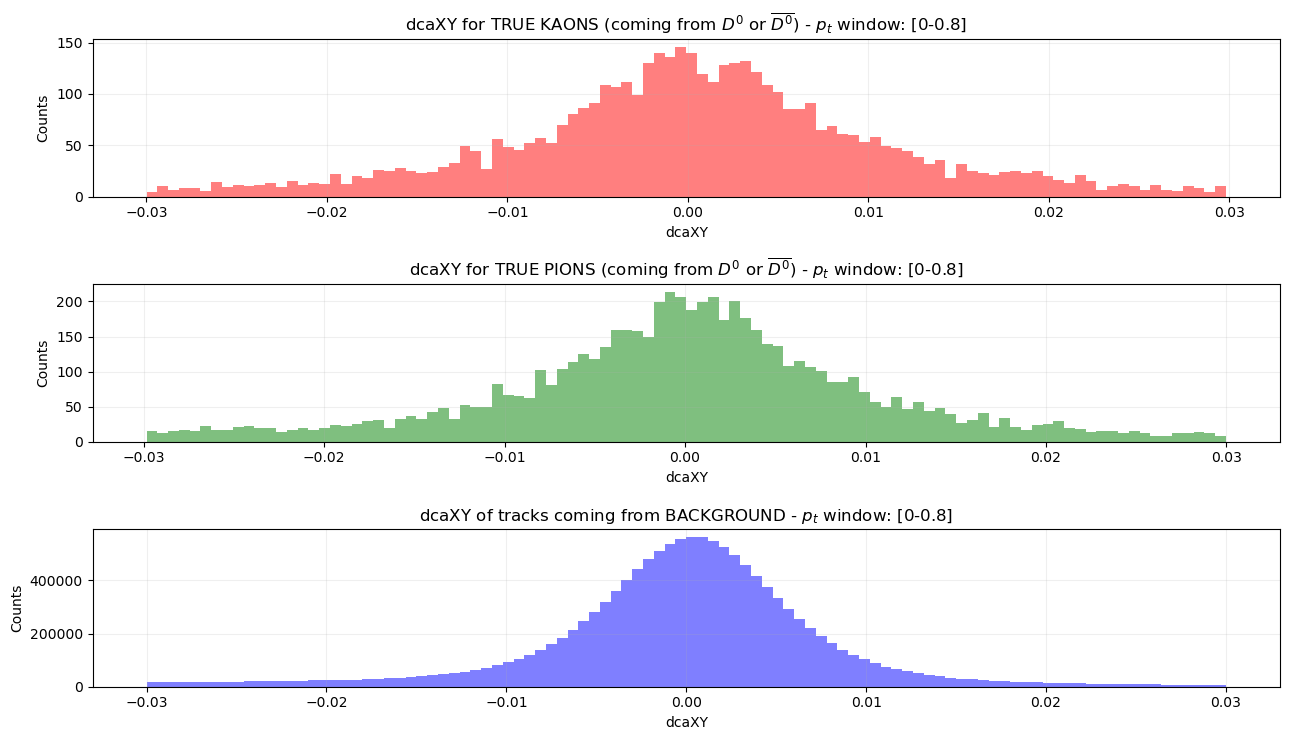

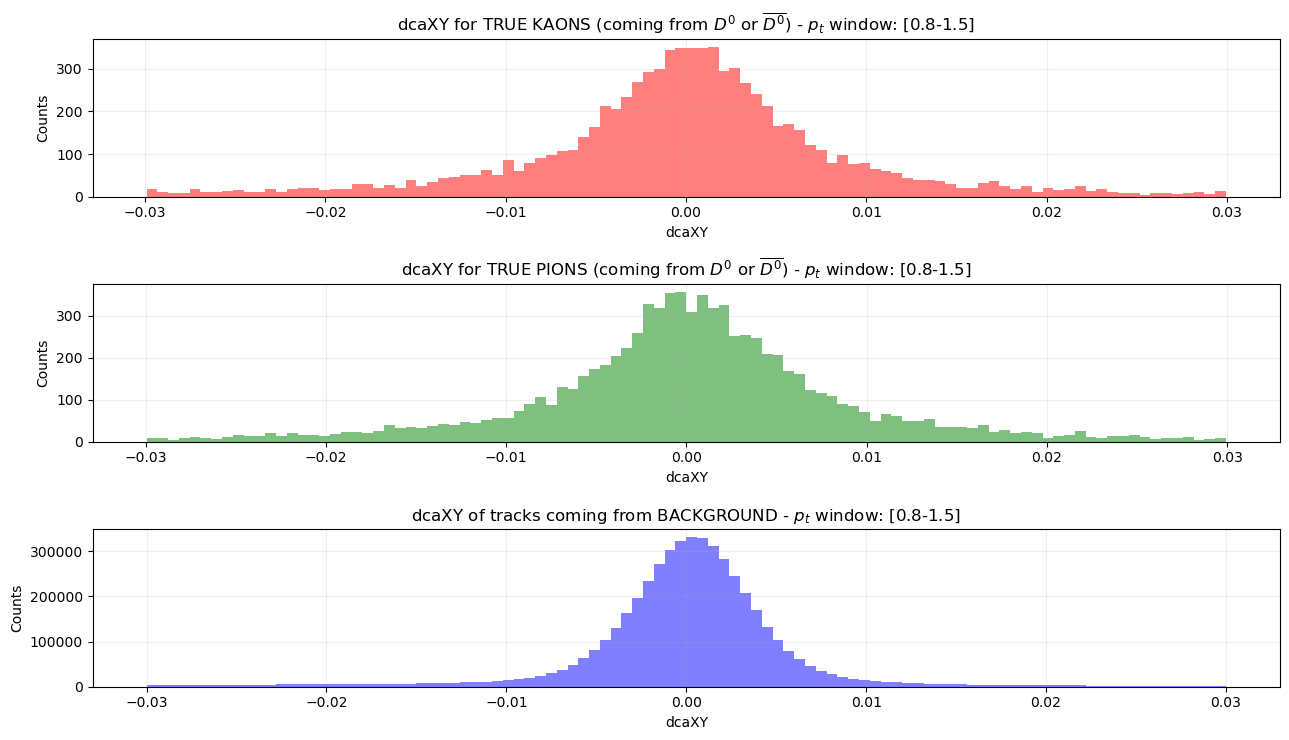

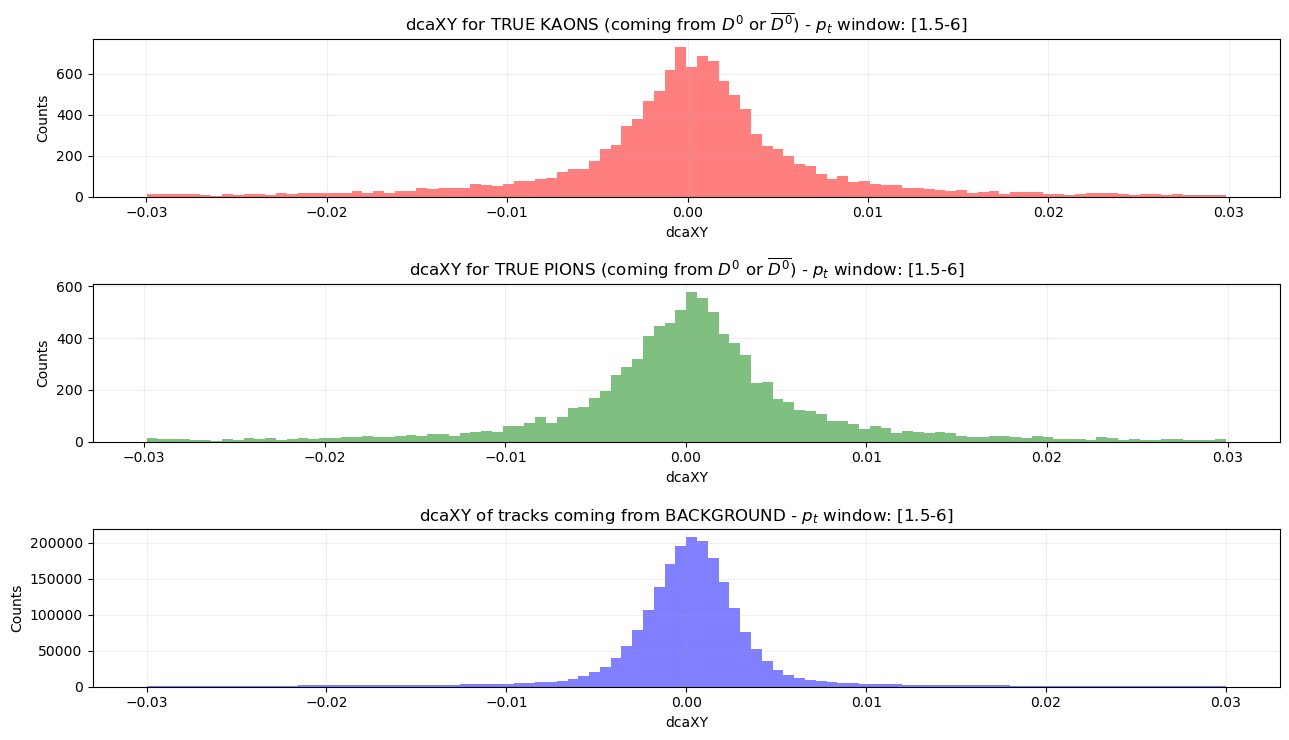

In [24]:
N_BINS = 100

for i, mask_name in enumerate(pt_windows_single_track):
    num_of_plots = 3
    fig, axs = plt.subplots(num_of_plots, 1, figsize=(13, 2.5 * num_of_plots))
    
    #-------------------------------------------------------------------
    # --- Plot dcaXY for k TRUE SIGNAL ---
    data = final_results.loc[ mask_true_k & multiple_masks_pt_single_track[i], 'fDcaXY'].values
    data = data[(data > -0.03) & (data < 0.03)]
    axs[0].hist(data, bins=N_BINS, color="red", alpha=0.5)
    axs[0].set_title(r"dcaXY for TRUE KAONS (coming from $D^0$ or $\overline{D^0}$) - $p_t$ window: " + str(mask_name))
    axs[0].set_xlabel("dcaXY")
    axs[0].set_ylabel("Counts")
    axs[0].grid(alpha=0.2)

    #-------------------------------------------------------------------
    # --- Plot dcaXY for pi TRUE SIGNAL ---
    data = final_results.loc[ mask_true_pi & multiple_masks_pt_single_track[i], 'fDcaXY'].values
    data = data[(data > -0.03) & (data < 0.03)]
    axs[1].hist(data, bins=N_BINS, color="green", alpha=0.5)
    axs[1].set_title(r"dcaXY for TRUE PIONS (coming from $D^0$ or $\overline{D^0}$) - $p_t$ window: " + str(mask_name))
    axs[1].set_xlabel("dcaXY")
    axs[1].set_ylabel("Counts")
    axs[1].grid(alpha=0.2)
    
    #-------------------------------------------------------------------
    # --- Plot dcaXY for BACKGROUND ---
    data = final_results.loc[ mask_background & multiple_masks_pt_single_track[i], 'fDcaXY'].values
    data = data[(data > -0.03) & (data < 0.03)]
    axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
    axs[2].set_title(r"dcaXY of tracks coming from BACKGROUND - $p_t$ window: " + str(mask_name))
    axs[2].set_xlabel("dcaXY")
    axs[2].set_ylabel("Counts")
    axs[2].grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()
    
    del data

We can see as, increasing $p_T$, the width of the distribution ecreases. This is due to resolution effect.  
Also we can see that the distribution of signal and BG are sadly alike.

## SEARCH FOR A CUT IN $dcaXY$
We search using both the sgnificance and the pseudo-signifiance S/sqrt(B) (just to have another pov).

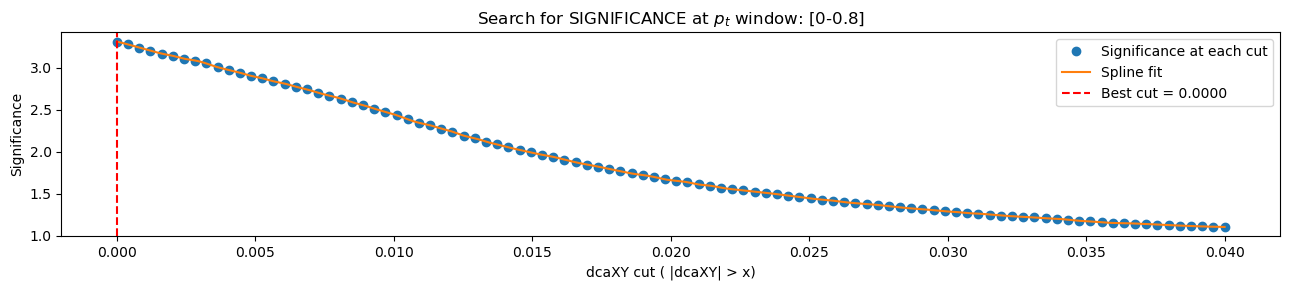

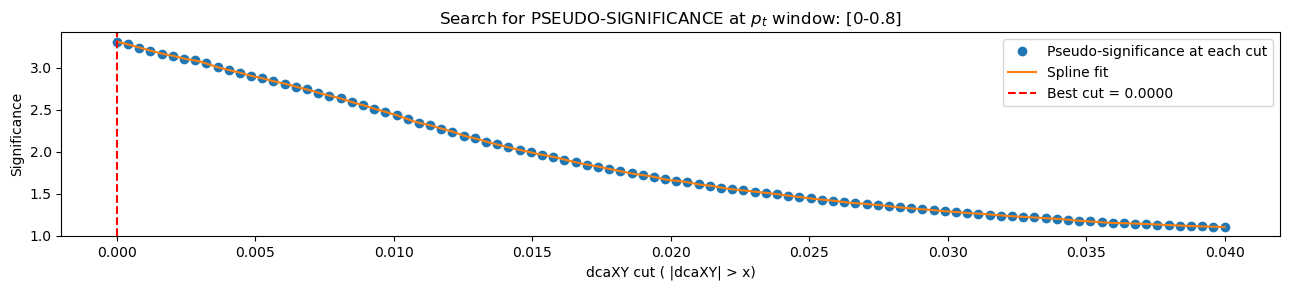

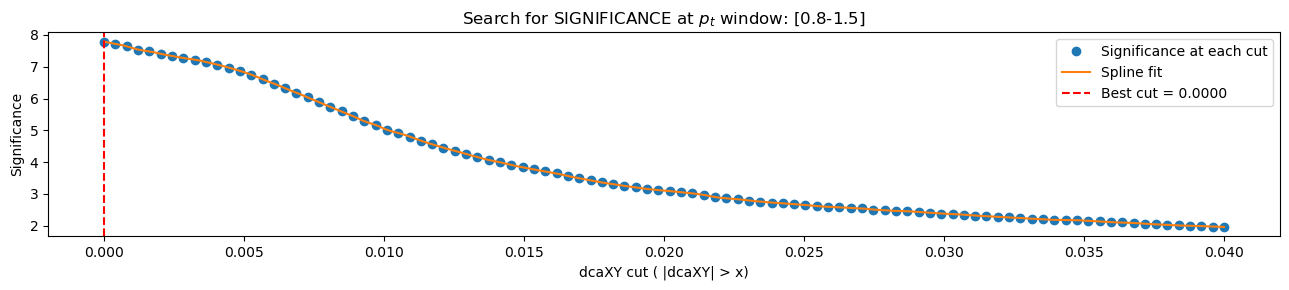

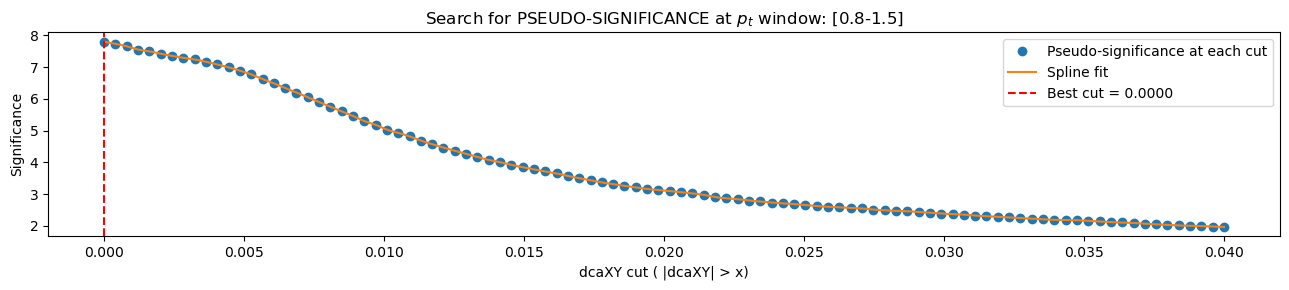

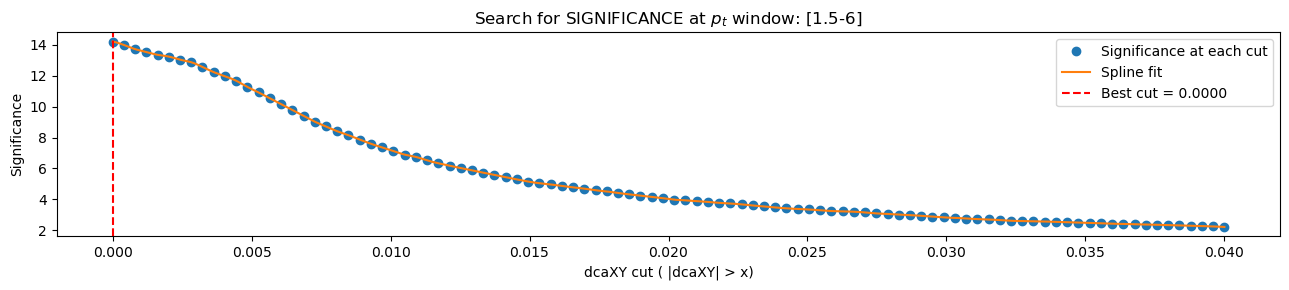

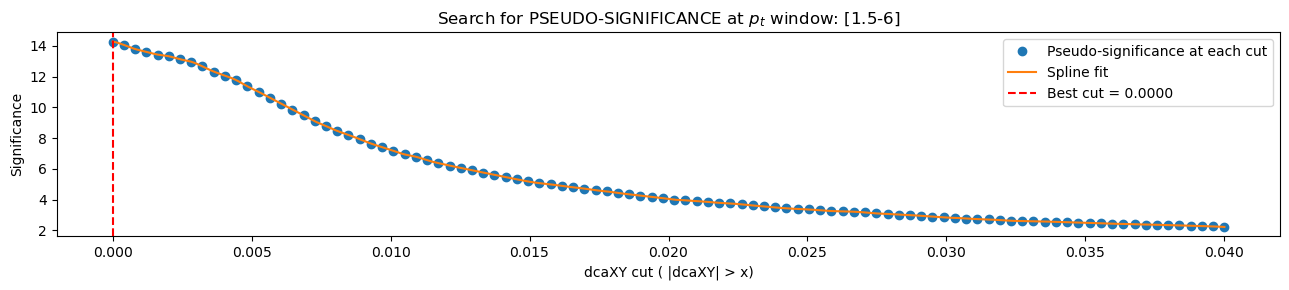

In [25]:
for i, mask_name in enumerate(pt_windows_single_track): 

    # initialization
    x_val = np.linspace( 0 , 0.04, 100)   # meaningful values for x axis
    y_val =[]              # this will save the significance value for each cut
    y_val_pseudo =[]       # this will save the pseudo-significance value for each cut
    
    signal_df = final_results.loc[ mask_signal & multiple_masks_pt_single_track[i], 'fDcaXY'].values
    background_df = final_results.loc[ mask_background & multiple_masks_pt_single_track[i], 'fDcaXY'].values

    # compute significance for |dcaXY| > x
    for x in x_val:
        s_count = np.sum(np.abs(signal_df) > x)
        b_count = np.sum(np.abs(background_df) > x)
        total = s_count + b_count
        y_val.append(       0 if total == 0   else s_count / np.sqrt(total))
        y_val_pseudo.append(0 if b_count == 0 else s_count / np.sqrt(b_count))
        
    
    # INTERPOLATION with spline:
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)                  # drawing the spline
    best_cut = x_dense[np.argmax(y_dense)]     # saving the cut that gives highest significance
    # pseudo-significance case:
    spline_pseudo = UnivariateSpline(x_val, y_val_pseudo, s=0)
    y_dense_pseudo = spline_pseudo(x_dense)                         # drawing the spline
    best_cut_pseudo = x_dense[np.argmax(y_dense_pseudo)]     # saving the cut that gives highest significance

    
    # PLOT:
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.set_title('Search for SIGNIFICANCE at $p_t$ window: ' + str(mask_name))
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
    ax.set_xlabel('dcaXY cut ( |dcaXY| > x)')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()
    # pseudo-significance case:
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val_pseudo, 'o', label='Pseudo-significance at each cut')
    ax.plot(x_dense, y_dense_pseudo, '-', label='Spline fit')
    ax.set_title('Search for PSEUDO-SIGNIFICANCE at $p_t$ window: ' + str(mask_name))
    ax.axvline(best_cut_pseudo, color='r', linestyle='--', label=f'Best cut = {best_cut_pseudo:.4f}')
    ax.set_xlabel('dcaXY cut ( |dcaXY| > x)')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()


The variable dcaXY doesn't seem to be useful.  
Also, the pseudo-significance doesn't tell us anything more than the significance. It's asically the same. This is because with huge background we have sqrt(S+B)=sart(B).

## SEARCH FOR BEST CUTS in TOF and TPC
Let's search (manually for now) for best cuts over the variables ['fNsigmaTOFka', 'fNsigmaTPCka'], appeared to be the best choices from previous plots.

In [18]:
search = "yes"

In [19]:
# ----------------------------------------------------------------------
#                       PID GRIDSEARCH FUNCTION
# ----------------------------------------------------------------------

def pid_grid_search(final_results,
                    mask_true_k, mask_true_pi,
                    pt_windows,
                    TOF_grid_k, TPC_grid_k,
                    TOF_grid_pi, TPC_grid_pi):
    
    # store results as dictiondaries
    results_k = {}   # kaons: {pt_window : (best_sig, best_cuts, matrix)}
    results_pi = {}  # pions: {pt_window : (best_sig, best_cuts, matrix)}

    # loop over pT windows
    for pt_range in pt_windows:

        # pt mask
        mask_pt = (final_results["fPt"] >= pt_range[0]) & (final_results["fPt"] < pt_range[1])
        # kaons data
        signal_k = final_results.loc[mask_true_k & mask_pt, ['fNsigmaTOFka', 'fNsigmaTPCka'] ]
        background_k = final_results.loc[ ~mask_true_k & mask_pt, ['fNsigmaTOFka', 'fNsigmaTPCka'] ]
        # (I use ~mask_true_k because if I use mask_background I would exclude also the pions from the background pov of kaons)
        # pions data
        signal_pi = final_results.loc[ mask_true_pi & mask_pt, ['fNsigmaTOFpi', 'fNsigmaTPCpi'] ]
        background_pi = final_results.loc[ ~mask_true_pi & mask_pt, ['fNsigmaTOFpi', 'fNsigmaTPCpi'] ]

        # --- KAONS SEARCH --------------------------------------------------
        # initialization
        sig_mat_k = np.zeros((len(TOF_grid_k), len(TPC_grid_k)))
        best_sig_k = 0         # best significance
        best_cuts_k = {}       # best cuts couple

        for i, cutTOF in enumerate(TOF_grid_k):
            for j, cutTPC in enumerate(TPC_grid_k):

                signal_pass = ( signal_k['fNsigmaTOFka'].between(-cutTOF, cutTOF) & signal_k['fNsigmaTPCka'].between(-cutTPC, cutTPC) )
                background_pass = ( background_k['fNsigmaTOFka'].between(-cutTOF, cutTOF) &
                                    background_k['fNsigmaTPCka'].between(-cutTPC, cutTPC)  )
                s = signal_pass.sum()
                b = background_pass.sum()

                sig = s / np.sqrt(s + b) if (s + b) > 0 else 0
                sig_mat_k[i, j] = sig    # we save significance value for heatmap

                if sig > best_sig_k:
                    best_sig_k = sig
                    best_cuts_k = {
                        "TOFka": round(cutTOF, 2),
                        "TPCka": round(cutTPC, 2)
                    }

        results_k[tuple(pt_range)] = (best_sig_k, best_cuts_k, sig_mat_k)

        # --- PIONS SEARCH --------------------------------------------------
        # initialization
        sig_mat_pi = np.zeros((len(TOF_grid_pi), len(TPC_grid_pi)))
        best_sig_pi = 0        # best significance
        best_cuts_pi = {}      # best cuts couple

        for i, cutTOF in enumerate(TOF_grid_pi):
            for j, cutTPC in enumerate(TPC_grid_pi):

                signal_pass = ( signal_pi['fNsigmaTOFpi'].between(-cutTOF, cutTOF) & signal_pi['fNsigmaTPCpi'].between(-cutTPC, cutTPC) )
                background_pass = ( background_pi['fNsigmaTOFpi'].between(-cutTOF, cutTOF) &
                                    background_pi['fNsigmaTPCpi'].between(-cutTPC, cutTPC)  )

                s = signal_pass.sum()
                b = background_pass.sum()

                sig = s / np.sqrt(s + b) if (s + b) > 0 else 0
                sig_mat_pi[i, j] = sig    # we save significance value for heatmap

                if sig > best_sig_pi:
                    best_sig_pi = sig
                    best_cuts_pi = {
                        "TOFpi": round(cutTOF, 2),
                        "TPCpi": round(cutTPC, 2)
                    }

        results_pi[tuple(pt_range)] = (best_sig_pi, best_cuts_pi, sig_mat_pi)

    return results_k, results_pi

In [21]:
# ----------------------------------------------------------------------
#                        PLOTTING HEATMAPS FUNCTION
# ----------------------------------------------------------------------

from matplotlib import cm

def heatmap_plots(pt_windows, results_k, results_pi,
                  TPC_grid_k, TOF_grid_k, TPC_grid_pi, TOF_grid_pi):
    for pt_range in pt_windows:
        pt_key = tuple(pt_range)

        # KAONS HEATMAP
        best_sig_k, best_cuts_k, sig_mat_k = results_k[pt_key]

        plt.figure(figsize=(4,3))
        plt.imshow(sig_mat_k,
                   origin='lower',
                   extent=[TPC_grid_k[0], TPC_grid_k[-1],
                           TOF_grid_k[0], TOF_grid_k[-1]],
                   aspect='auto',
                   cmap='viridis')
        plt.colorbar(label=r"$\frac{S}{\sqrt{S+B}}$")

        plt.title(f"$Kaons$ significance - $p_T$ {pt_range} GeV/c")
        plt.xlabel("TPCka cut (±)")
        plt.ylabel("TOFka cut (±)")

        # best point
        plt.scatter(best_cuts_k["TPCka"], best_cuts_k["TOFka"],
                    color="red", s=80, marker="x")

        plt.tight_layout()
        plt.savefig(f"images/2D_search_TOF_TPC_ka_pt{pt_range}.png")
        plt.show()

        # PIONS HEATMAP
        best_sig_pi, best_cuts_pi, sig_mat_pi = results_pi[pt_key]

        plt.figure(figsize=(4,3))
        plt.imshow(sig_mat_pi,
                   origin='lower',
                   extent=[TPC_grid_pi[0], TPC_grid_pi[-1],
                           TOF_grid_pi[0], TOF_grid_pi[-1]],
                   aspect='auto',
                   cmap='magma')
        plt.colorbar(label=r"$\frac{S}{\sqrt{S+B}}$")

        plt.title(f"$Pions$ significance - $p_T$ {pt_range} GeV/c")
        plt.xlabel("TPCpi cut (±)")
        plt.ylabel("TOFpi cut (±)")

        # best point
        plt.scatter(best_cuts_pi["TPCpi"], best_cuts_pi["TOFpi"],
                    color="cyan", s=80, marker="x")

        plt.tight_layout()
        plt.savefig(f"images/2D_search_TOF_TPC_pi_pt{pt_range}.png")
        plt.show()

In [20]:
# ------------  DEFINE PARAMETERS  -------------------------------------------------
pt_windows = [
    (0, 1.5),
    (1.5, 6),
]

TOF_grid_k = np.linspace(2, 13, 40)
TPC_grid_k = np.linspace(0.5, 7, 40)

TOF_grid_pi = np.linspace(5, 13, 40)
TPC_grid_pi = np.linspace(0.5, 7, 40)

# ------------- RUN PID GRID SEARCH  --------------------------

if search == "yes":
    
    results_k, results_pi = pid_grid_search(
        final_results,
        mask_true_k, mask_true_pi,
        pt_windows,
        TOF_grid_k, TPC_grid_k,
        TOF_grid_pi, TPC_grid_pi
    )
    
    # ---------- PRINT SUMMARY OF RESULTS -----------------------------
    print("\n===== SUMMARY OF SEARCH =====")
    for species, results in zip(["Kaons", "Pions"], [results_k, results_pi]):
        print(f"\n--- {species.upper()} ---")
        for pt_range, (sig, cuts, _) in results.items():
            cuts_str = ", ".join([f"{k}=±{v:.2f}" for k, v in cuts.items()])
            print(f"pT {pt_range} → Signif={sig:.4f}, cuts=({cuts_str})")


===== SUMMARY OF SEARCH =====

--- KAONS ---
pT (0, 1.5) → Signif=5.5491, cuts=(TOFka=±5.67, TPCka=±2.67)
pT (1.5, 6) → Signif=7.2572, cuts=(TOFka=±6.51, TPCka=±1.50)

--- PIONS ---
pT (0, 1.5) → Signif=2.8176, cuts=(TOFpi=±11.97, TPCpi=±3.33)
pT (1.5, 6) → Signif=4.9634, cuts=(TOFpi=±10.74, TPCpi=±2.17)


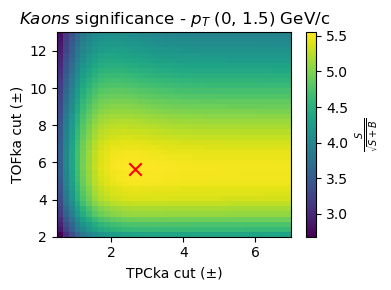

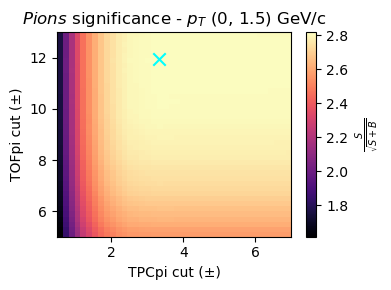

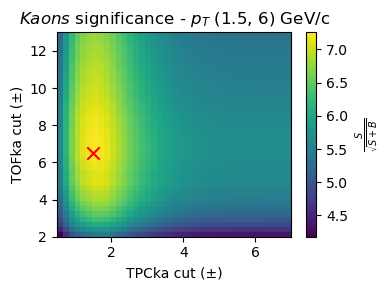

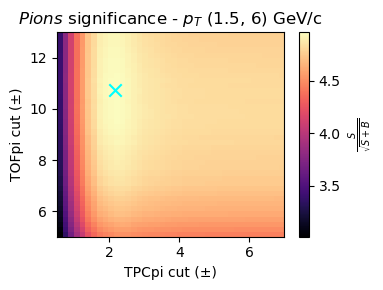

In [22]:
# -------------------------------------------------------------
#                     PLOT HEATMAPS
# -------------------------------------------------------------
if search == "yes":
    heatmap_plots(
        pt_windows,
        results_k, results_pi,
        TPC_grid_k, TOF_grid_k,
        TPC_grid_pi, TOF_grid_pi
    )

#### SEARCH CONCLUSION
From the two–dimensional significance maps, clear differences emerge between kaon and pion PID optimization.

For kaons, well-defined regions of increased significance are visible, indicating that PID cuts are highly effective. In particular, at low transverse momentum, the dominant discriminating variable is TOFka: once TPCka exceeds a threshold of approximately 1–2σ, further tightening of the TPC cut does not lead to a significant improvement in significance. In this pT region, TOF information provides the main separation power. At higher pT, the relative contribution of TPC and TOF becomes more balanced.

For pions, instead, the significance remains approximately uniform over the entire explored PID cut space. This behavior reflects the intrinsic difficulty of identifying pions originating from D⁰ decays, as the background is itself largely composed of pions. As a consequence, PID cuts on TPCpi and TOFpi offer limited discriminating power, leading to marginal improvements in significance across the search region.

---

## SEARCH FOR BEST CUTS in TPC without TOF
Let's search (manually for now) for best cuts over the variable 'fNsigmaTPCka' for when we do not have the TOF data (TOF=-999).

In [69]:
search = "no"

In [23]:
# ----------------------------------------------------------------------
#                       PID GRIDSEARCH FUNCTION
# ----------------------------------------------------------------------

def tpc_search(final_results,
                    mask_true_k, mask_true_pi,
                    pt_windows,
                    TPC_grid_k, TPC_grid_pi):
    
    # store results as dictiondaries
    results_k = {}   # kaons: {pt_window : (best_sig, best_cuts, matrix)}
    results_pi = {}  # pions: {pt_window : (best_sig, best_cuts, matrix)}

    # loop over pT windows
    for pt_range in pt_windows:

        # pt mask
        mask_pt = (final_results["fPt"] >= pt_range[0]) & (final_results["fPt"] < pt_range[1])
        # kaons data
        signal_k = final_results.loc[ mask_true_k & mask_pt & (final_results["fNsigmaTOFka"] == -999), ["fNsigmaTPCka"]  ]
        background_k = final_results.loc[ (~mask_true_k) & mask_pt & (final_results["fNsigmaTOFka"] == -999),  ["fNsigmaTPCka"]  ]
        # (I use ~mask_true_k because if I use mask_background I would exclude also the pions from the background pov of kaons)
        # pions data
        signal_pi = final_results.loc[ mask_true_pi & mask_pt & (final_results["fNsigmaTOFpi"] == -999), ["fNsigmaTPCpi"] ]
        background_pi = final_results.loc[ (~mask_true_pi) & mask_pt & (final_results["fNsigmaTOFpi"] == -999), ["fNsigmaTPCpi"] ]

        # --- KAONS SEARCH --------------------------------------------------
        # initialization
        sig_k = np.zeros( len(TPC_grid_k) )
        best_sig_k = 0         # best significance
        best_cut_k = {}        # best cut

        for i, cutTPC in enumerate(TPC_grid_k):

            signal_pass =  signal_k['fNsigmaTPCka'].between(-cutTPC, cutTPC)
            background_pass = background_k['fNsigmaTPCka'].between(-cutTPC, cutTPC)
            s = signal_pass.sum()
            b = background_pass.sum()

            sig = s / np.sqrt(s + b) if (s + b) > 0 else 0
            sig_k[i] = sig    # we save significance value for heatmap

            if sig > best_sig_k:
                best_sig_k = sig
                best_cut_k = { "TPCka": round(cutTPC, 2) }

        results_k[tuple(pt_range)] = (best_sig_k, best_cut_k, sig_k)

        # --- PIONS SEARCH --------------------------------------------------
        # initialization
        sig_pi = np.zeros( len(TPC_grid_pi) )
        best_sig_pi = 0        # best significance
        best_cut_pi = {}       # best cut

        for i, cutTPC in enumerate(TPC_grid_pi):

            signal_pass = signal_pi['fNsigmaTPCpi'].between(-cutTPC, cutTPC)
            background_pass = background_pi['fNsigmaTPCpi'].between(-cutTPC, cutTPC)

            s = signal_pass.sum()
            b = background_pass.sum()

            sig = s / np.sqrt(s + b) if (s + b) > 0 else 0
            sig_pi[i] = sig    # we save significance value for heatmap

            if sig > best_sig_pi:
                best_sig_pi = sig
                best_cut_pi = { "TPCpi": round(cutTPC, 2) }

        results_pi[tuple(pt_range)] = (best_sig_pi, best_cut_pi, sig_pi)

    return results_k, results_pi

In [24]:
# ----------------------------------------------------------------------
#                PLOTTING 1D SIGNIFICANCE vs TPC CUT
# ----------------------------------------------------------------------

def plot_tpc_search(pt_windows, results_k, results_pi,
                    TPC_grid_k, TPC_grid_pi):

    for pt_range in pt_windows:
        pt_key = tuple(pt_range)

        # ==================== KAONS ====================
        best_sig_k, best_cut_k, sig_k = results_k[pt_key]

        plt.figure(figsize=(4,3))
        plt.plot(TPC_grid_k, sig_k, marker='o', ms=3, lw=1, label='Significance')
        plt.axvline(best_cut_k["TPCka"], color='red', ls='--',
                    label=f'Best cut = ±{best_cut_k["TPCka"]:.2f}')

        plt.xlabel("TPCka cut (±)")
        plt.ylabel(r"$\frac{S}{\sqrt{S+B}}$")
        plt.title(f"$Kaons$ TPC-only PID — $p_T$ {pt_range} GeV/c")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"images/1D_search_TPC_ka_pt{pt_range}.png")
        plt.show()

        # ==================== PIONS ====================
        best_sig_pi, best_cut_pi, sig_pi = results_pi[pt_key]

        plt.figure(figsize=(4,3))
        plt.plot(TPC_grid_pi, sig_pi, marker='o', ms=3, lw=1,
                 color='darkorange', label='Significance')
        plt.axvline(best_cut_pi["TPCpi"], color='cyan', ls='--',
                    label=f'Best cut = ±{best_cut_pi["TPCpi"]:.2f}')

        plt.xlabel("TPCpi cut (±)")
        plt.ylabel(r"$\frac{S}{\sqrt{S+B}}$")
        plt.title(f"$Pions$ TPC-only PID — $p_T$ {pt_range} GeV/c")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"images/1D_search_TPC_pi_pt{pt_range}.png")
        plt.show()


In [25]:
# ------------  DEFINE PARAMETERS  -------------------------------------------------
pt_windows = [
    (0, 1.5),
    (1.5, 6),
]

TPC_grid_k = np.linspace(0.5, 7, 40)
TPC_grid_pi = np.linspace(0.5, 7, 40)

# ------------- RUN PID GRID SEARCH  --------------------------
if search == "yes":
    results_k, results_pi = tpc_search(
        final_results,
        mask_true_k, mask_true_pi,
        pt_windows,
        TPC_grid_k, TPC_grid_pi
    )
    
    # ---------- PRINT SUMMARY OF RESULTS -----------------------------
    print("\n===== SUMMARY OF SEARCH =====")
    for species, results in zip(["Kaons", "Pions"], [results_k, results_pi]):
        print(f"\n--- {species.upper()} ---")
        for pt_range, (sig, cuts, _) in results.items():
            cuts_str = ", ".join([f"{k}=±{v:.2f}" for k, v in cuts.items()])
            print(f"pT {pt_range} → Signif={sig:.4f}, cuts=({cuts_str})")


===== SUMMARY OF SEARCH =====

--- KAONS ---
pT (0, 1.5) → Signif=4.7364, cuts=(TPCka=±1.67)
pT (1.5, 6) → Signif=6.6520, cuts=(TPCka=±1.50)

--- PIONS ---
pT (0, 1.5) → Signif=2.5685, cuts=(TPCpi=±3.00)
pT (1.5, 6) → Signif=4.2332, cuts=(TPCpi=±2.00)


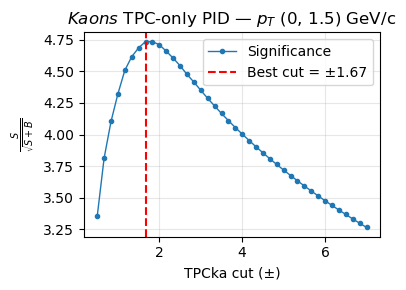

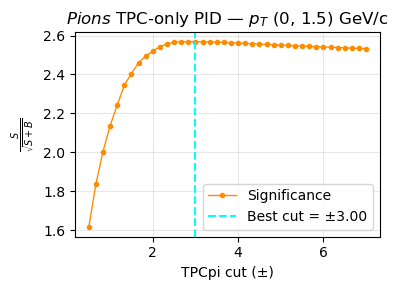

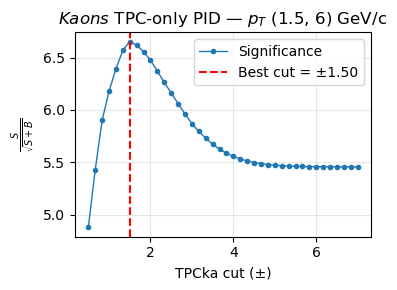

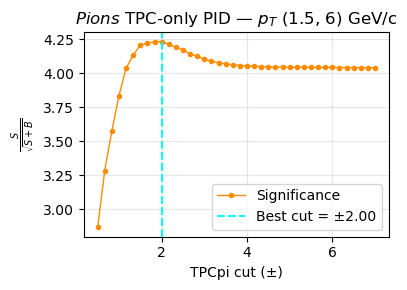

In [26]:
if search == "yes":
    plot_tpc_search(
        pt_windows,
        results_k,
        results_pi,
        TPC_grid_k,
        TPC_grid_pi
    )

When restricting the analysis to the 1D PID search in TPC only (i.e. tracks with fixed TOF = −999), the optimal cuts found on the TPC variables are generally consistent with those obtained in the full 2D (TPC+TOF) optimization. However, the achieved significance is systematically lower.

The most notable difference is observed for kaons at low transverse momentum, where the optimal TPCka cut shifts from approximately ±2.67 in the 2D case to ±1.67 in the 1D-only optimization. This behavior is consistent with previous observations: at low pT, TOFka provides the dominant discriminating power, and once TOF information is removed, tighter TPC cuts are required to partially compensate for the loss of separation.

Overall, the reduced significance in the TPC-only case reflects the absence of TOF information, which limits the achievable particle identification performance, especially at low pT.

Therefore, while a TPC-only approach remains viable for tracks without TOF matching, the inclusion of TOF information is essential to maximize the statistical significance of the D⁰ signal, especially in the low-pT region.

Best cuts found in the last run:
```
CUTS FROM 2D SEARCH (using both TPC anf TOF):

--- KAONS ---
pT (0, 1.5) → Signif=5.5491, cuts=(TOFka=±5.67, TPCka=±2.67)
pT (1.5, 6) → Signif=7.2572, cuts=(TOFka=±6.51, TPCka=±1.50)

--- PIONS ---
pT (0, 1.5) → Signif=2.8176, cuts=(TOFpi=±11.97, TPCpi=±3.33)
pT (1.5, 6) → Signif=4.9634, cuts=(TOFpi=±10.74, TPCpi=±2.17)


CUTS FROM 1D SEARCH (only on TPC):

--- KAONS ---
pT (0, 1.5) → Signif=4.7364, cuts=(TPCka=±1.67)
pT (1.5, 6) → Signif=6.6520, cuts=(TPCka=±1.50)

--- PIONS ---
pT (0, 1.5) → Signif=2.5685, cuts=(TPCpi=±3.00)
pT (1.5, 6) → Signif=4.2332, cuts=(TPCpi=±2.00)
```

---

---

---